In [41]:
import os
import pandas as pd
import numpy as np
import regex as re
import mytrain_lib_cluster as ml
import json
import torch
from torch import functional as f
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import importlib as il
%matplotlib inline

In [42]:
path_results = 'F://TFG//results//'
path_scores  = path_results + 'scores//'
path_graphs = 'F://TFG//graphs//'
path_summary = path_graphs + 'summary//'
path_outputs = path_results + 'outputs//'

## Proof of Concept

Queremos sacar:
- Configuraciones con mejores accuracy en el test
- Configuraciones con menor y mayor bias (underfitting) y variance (overfitting)
- Hiperparámetros con mayor varianza en el error y accuracy &rarr; más críticos
- Hiperparámetros con menor varianza en el error y accuracy &rarr; menos críticos
- Configuraciones con más y menos precisión y recall
- Analizar AUC-ROC

In [242]:
with open(path_scores+'config.json','r') as config:
    res = json.load(config)

In [243]:
res[0].get('acc_test',-1)

0.4407894736842105

In [244]:
accuracy = []
for c in res:
    accuracy.append(c.get('acc_test',-1))
accuracy = np.array(accuracy)

In [245]:
accuracy[794]

0.51171875

In [246]:
res[0].keys()

dict_keys(['temp', 'path', 'confnum', 'model', 'config_model', 'optimizer', 'config_optimizer', 'criterion', 'scaler', 'batch_size', 'epochs', 'cv_results', 'error_train', 'acc_train', 'error_test', 'acc_test', 'cm'])

In [247]:
print(res[0]['config_model'].keys())
print(res[0]['config_optimizer'].keys())
print(res[1]['config_optimizer'].keys())

dict_keys(['hidden_neurons', 'p'])
dict_keys(['momentum', 'weight_decay', 'nesterov', 'dampening', 'lr'])
dict_keys(['weight_decay', 'betas', 'lr'])


#### Configurations with highest test accuracy

In [248]:
def get_accuracy(config):
    return config.get('acc_test',None)

def get_error(config):
    error = config.get('error_train',None)
    if error>1000: error = np.nan
    return error

def get_bias(config):
    return get_error(config)

def get_variance(config):
    return config.get('error_test',get_bias(config)*2) - get_bias(config) 

def get_diff_biasvariance(config):
    return get_variance(config) - get_bias(config)

def get_sorted_configs(jsons,operation,order='max',n=5,return_index=True):
    jsons = np.array(jsons)
    acc_list = list(map(operation,jsons))
    indexes = np.array(acc_list).argsort()
    if order=='max': indexes = indexes[-n:][::-1]
    elif order=='min': pass
    else: raise Exception('Value have to be "min" or "max"') 
    indexes = indexes[:n] 

    if return_index: 
        return indexes
    else: 
        return jsons[indexes]

def architecture_string(nn):
    _r_ = ''
    for n in nn:
        _r_ += str(n) + '_'
    return _r_[:-1]

def df_config(jsons):
    return -1

In [249]:
get_sorted_configs(res, get_accuracy, order='max', n=5, return_index=1)

array([794, 714, 245, 717, 428], dtype=int64)

In [250]:
get_sorted_configs(res, get_error, order='min', n=5, return_index=1)

array([950, 448, 967, 670, 768], dtype=int64)

In [251]:
get_sorted_configs(res, get_variance, order='min')

array([516, 880, 549, 767, 163], dtype=int64)

In [252]:
res[0].keys()

dict_keys(['temp', 'path', 'confnum', 'model', 'config_model', 'optimizer', 'config_optimizer', 'criterion', 'scaler', 'batch_size', 'epochs', 'cv_results', 'error_train', 'acc_train', 'error_test', 'acc_test', 'cm'])

In [253]:
res[0]['model']

"<class 'goalnets.NeuralNetworkDOClass'>"

In [254]:
def get_class(strclass):
    if '.' not in strclass:
        return strclass
    return strclass.split("'")[1].split('.')[-1]

get_class("<class 'torch.nn.modules.loss.CrossEntropyLoss'>")

def get_betas(betas):
    if betas is not None:
        return betas[0], betas[1]
    else: return np.NAN, np.NAN

In [255]:
df = pd.DataFrame({})

for r in res:
    serie = pd.Series(dtype=object)
    serie['confnum'] = r.get('confnum',None)[0]
    serie['model'] = get_class(r.get('model',None))
    serie['architecture'] = architecture_string(r['config_model'].get('hidden_neurons',None))
    serie['p'] = r['config_model'].get('p',0)
    serie['optimizer'] = get_class(r['optimizer'])
    # optim params
    serie['momentum'] = r['config_optimizer'].get('momentum',None)
    serie['weight_decay'] = r['config_optimizer'].get('weight_decay',None)
    serie['nesterov'] = r['config_optimizer'].get('nesterov',None)
    serie['dampening'] = r['config_optimizer'].get('dampening',None)
    serie['lr'] = r['config_optimizer'].get('lr',None)
    serie['weight_decay'] = r['config_optimizer'].get('weight_decay',None)
    serie['b1'], serie['b2'] = get_betas(r['config_optimizer'].get('betas',None))
    serie['lr'] = r['config_optimizer'].get('lr',None)   
    serie['criterion'] = get_class(r['criterion'])
    serie['scaler'] = get_class(r['scaler'])
    serie['batch_size'] = r['batch_size']
    serie['epochs'] = r['epochs']
    # metrics
    serie['error_train'] = get_error(r)
    serie['error_test'] = r.get('error_test',np.NAN)
    serie['acc_train'] = r.get('acc_train',np.NAN)
    serie['acc_test'] = get_accuracy(r)
    # compute recall, recall, AUC...

    df = pd.concat([df,serie],axis=1,ignore_index=True)

df = df.T.set_index('confnum').fillna(value=np.nan)

In [256]:
df

,model,architecture,p,optimizer,momentum,weight_decay,nesterov,dampening,lr,b1,b2,criterion,scaler,batch_size,epochs,error_train,error_test,acc_train,acc_test
confnum,,,,,,,,,,,,,,,,,,,
0,NeuralNetworkDOClass,120_50_25,0.120553,SGD,0.891773,0.000000,0.0,0.000000,0.00100,NaN,NaN,CrossEntropyLoss,basic,16,250,0.817060,1.516803,0.635110,0.440789
1,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.10000,0.832620,0.799159,CrossEntropyLoss,MinMaxScaler,32,250,1.072742,1.089138,0.455882,0.451389
2,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.832620,0.990000,CrossEntropyLoss,basic,64,250,0.905230,1.245437,0.576287,0.464844
3,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.778157,0.990000,CrossEntropyLoss,Normalizer,16,250,0.883490,1.247529,0.584559,0.467105
4,NeuralNetworkBNClass,120_50_25,0.000000,Adam,NaN,0.000000,NaN,NaN,0.00001,0.001000,0.010000,CrossEntropyLoss,basic,128,250,0.924791,1.127353,0.573242,0.453125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NeuralNetworkDOClass,120_50_25,0.108977,Adam,NaN,0.000000,NaN,NaN,0.00010,0.001000,0.978618,CrossEntropyLoss,MaxAbsScaler,128,250,0.962390,1.161603,0.539062,0.488281
996,NeuralNetworkDOClass,120_50_25,0.109763,SGD,0.963663,0.000000,0.0,0.043565,0.00010,NaN,NaN,CrossEntropyLoss,MaxAbsScaler,16,250,1.000533,1.149259,0.516544,0.483553
997,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.211827,NaN,NaN,0.00100,0.778157,0.870012,CrossEntropyLoss,StandardScaler,64,250,1.069350,1.070615,0.455882,0.449219


In [257]:
error_grouping = df.groupby(['weight_decay']).agg(
    {'scaler': ['count'], 'error_train': ['mean','min', 'var'], 'acc_test':['mean','max', 'var']}
)
error_grouping

scaler error_train                       acc_test            \
              count        mean       min        var      mean       max   
weight_decay                                                               
0.000000        613    0.807769  0.000000   0.135602  0.447623  0.511719   
0.211827        143    1.189541  0.531121   2.871058  0.449543  0.496528   
0.218794        122    1.056305  0.742417   0.003401  0.450520  0.493056   
0.322947        122    1.743710  0.237242  48.454698  0.449708  0.480469   

                        
                   var  
weight_decay            
0.000000      0.001765  
0.211827      0.000449  
0.218794      0.000268  
0.322947      0.000194

In [2]:
'anova' in 'ANOVA'.lower()

True

In [258]:
(pd.DataFrame(error_grouping.var(),columns=['weight_decay']).T
                            .drop(['scaler',('error_train','var'),('acc_test','var')],axis=1))

error_train            acc_test          
                    mean       min      mean       max
weight_decay    0.156741  0.106314  0.000002  0.000165

In [259]:
def fun_grouped_error(c):
    return df.groupby(c).agg(
                                {'scaler': ['count'],
                                 'error_train': ['mean','min', 'var'],
                                 'acc_test':['mean','max', 'var']
                                }
                            )

In [260]:
cols = ['model', 'p', 'optimizer', 'momentum', 'weight_decay',
       'nesterov', 'dampening', 'lr', 'b1', 'b2', 'scaler',
       'batch_size']

errorvar_hyperparams = pd.DataFrame()
for c in cols:
    grouped_error = fun_grouped_error(c)
    # if isinstance(c,list): c = 'betas'
    resume_error = (pd.DataFrame(grouped_error.var(),columns=[c]).T
                            .drop(['scaler',('error_train','var'),('acc_test','var')],axis=1))
    errorvar_hyperparams = pd.concat([errorvar_hyperparams,resume_error])

In [261]:
errorvar_hyperparams = errorvar_hyperparams.sort_values(('acc_test','max'),ascending=False)
errorvar_hyperparams

error_train                    acc_test          
                    mean           min          mean       max
weight_decay    0.156741  1.063141e-01  1.505547e-06  0.000165
nesterov        0.001268  1.506290e-11  3.307718e-07  0.000069
model           0.075156  4.738715e-02  1.155655e-04  0.000063
b1              0.243590  3.492101e-15  9.145344e-05  0.000036
dampening       0.002128  1.116644e-09  1.167180e-06  0.000022
p               0.081974  3.862207e-02  4.683888e-05  0.000020
momentum        0.000451  4.371353e-07  1.883925e-06  0.000019
lr              0.044317  1.102332e-01  3.971861e-05  0.000012
b2              0.727584  1.719064e-05  2.672485e-04  0.000011
scaler          0.046393  3.656168e-11  1.691863e-05  0.000009
optimizer       0.021617  6.219318e-10  7.778940e-05  0.000008
batch_size      0.019053  2.984961e-11  1.713354e-06  0.000005

In [262]:
fun_grouped_error('lr')

scaler error_train                           acc_test            \
         count        mean           min        var      mean       max   
lr                                                                        
0.00001    198    1.044507  7.424171e-01   0.002471  0.455325  0.507812   
0.00010    199    0.939830  1.092696e-05   0.070871  0.454701  0.503906   
0.00100    205    0.867606  1.321382e-07   0.119819  0.447606  0.509868   
0.01000    181    0.809070  0.000000e+00   0.148641  0.443878  0.503906   
0.10000    217    1.343053  3.526845e-05  29.937265  0.441310  0.511719   

                   
              var  
lr                 
0.00001  0.000193  
0.00010  0.000758  
0.00100  0.001310  
0.01000  0.002161  
0.10000  0.001504

<BarContainer object of 12 artists>

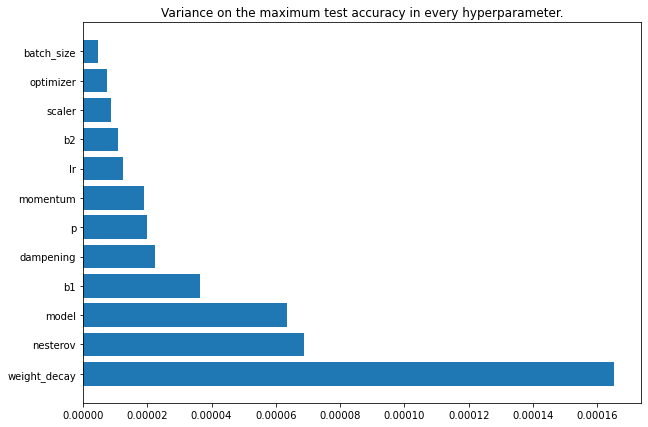

In [263]:
plt.figure(figsize=(10,7))
plt.title('Variance on the maximum test accuracy in every hyperparameter.')
plt.barh(y=errorvar_hyperparams.index,width=errorvar_hyperparams[('acc_test','max')])
# plt.savefig(path_summary + 'randomsearch_varmaxtestacc' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

<BarContainer object of 12 artists>

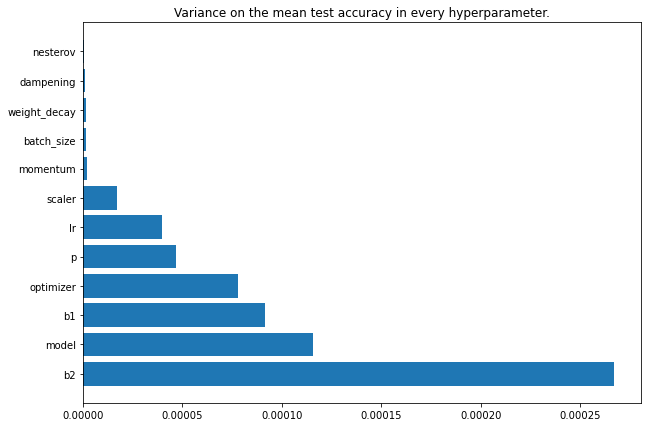

In [264]:
plt.figure(figsize=(10,7))
plt.title('Variance on the mean test accuracy in every hyperparameter.')
data_plot = errorvar_hyperparams.sort_values(('acc_test','mean'),ascending=False)
plt.barh(y=data_plot.index,width=data_plot[('acc_test','mean')])
# plt.savefig(path_summary + 'randomsearch_varmeantestacc' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

In [265]:
fun_grouped_error('lr')

scaler error_train                           acc_test            \
         count        mean           min        var      mean       max   
lr                                                                        
0.00001    198    1.044507  7.424171e-01   0.002471  0.455325  0.507812   
0.00010    199    0.939830  1.092696e-05   0.070871  0.454701  0.503906   
0.00100    205    0.867606  1.321382e-07   0.119819  0.447606  0.509868   
0.01000    181    0.809070  0.000000e+00   0.148641  0.443878  0.503906   
0.10000    217    1.343053  3.526845e-05  29.937265  0.441310  0.511719   

                   
              var  
lr                 
0.00001  0.000193  
0.00010  0.000758  
0.00100  0.001310  
0.01000  0.002161  
0.10000  0.001504

Text(0, 0.5, 'test accuracy')

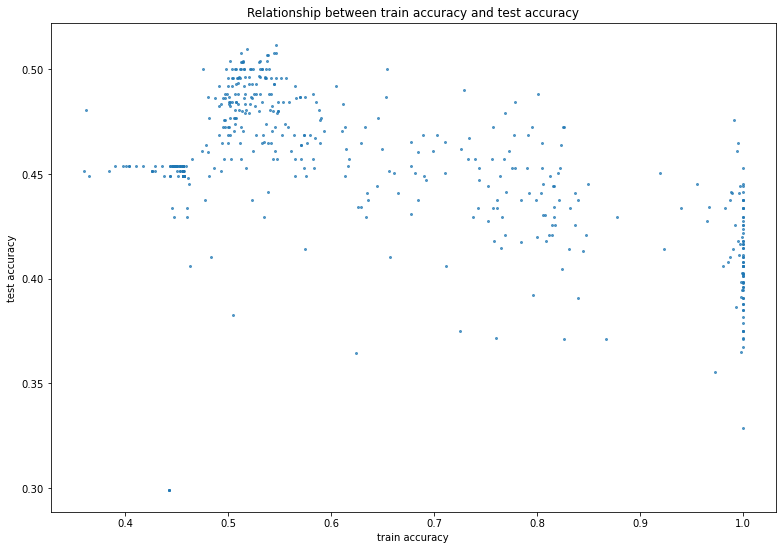

In [266]:
#   SCATTER PLOT - train_error vs test_acc
data_plot = df[df.error_train<3]
plt.figure(figsize=(13,9))
plt.title('Relationship between train accuracy and test accuracy')
plt.scatter(x=data_plot.acc_train,y=data_plot.acc_test, alpha=.7, s=4)
plt.xlabel('train accuracy'); plt.ylabel('test accuracy')
# plt.savefig(path_summary + 'scatter_trainacc_testacc' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

Son las configuraciones que estan por el medio las que más me interesan y que pueden tener potencial para mejorar el accuracy en el test.

(0.0, 20.0)

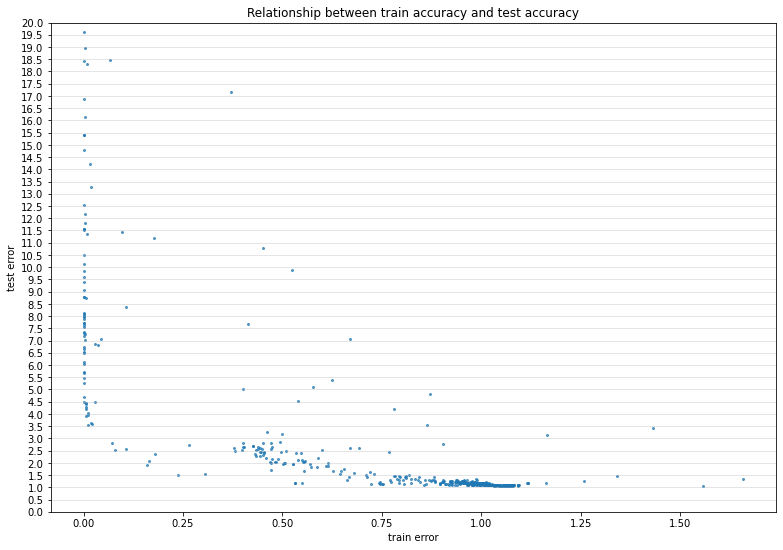

In [267]:
#   SCATTER PLOT - train_error vs test_acc
data_plot = df[df.error_train<3]
plt.figure(figsize=(13,9))
plt.title('Relationship between train accuracy and test accuracy')
plt.scatter(x=data_plot.error_train,y=data_plot.error_test, alpha=.7, s=4)
plt.xlabel('train error'); plt.ylabel('test error')
plt.yticks(np.linspace(start=0,stop=22,num=45))
plt.grid(axis='y',alpha=.4)
plt.ylim(0,20)
# plt.savefig(path_summary + 'scatter_trainerror_testerror' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

Vemos aqui como se distribuye el error (train y test) en las diferentes configuraciones.

Text(0, 0.5, 'test accuracy')

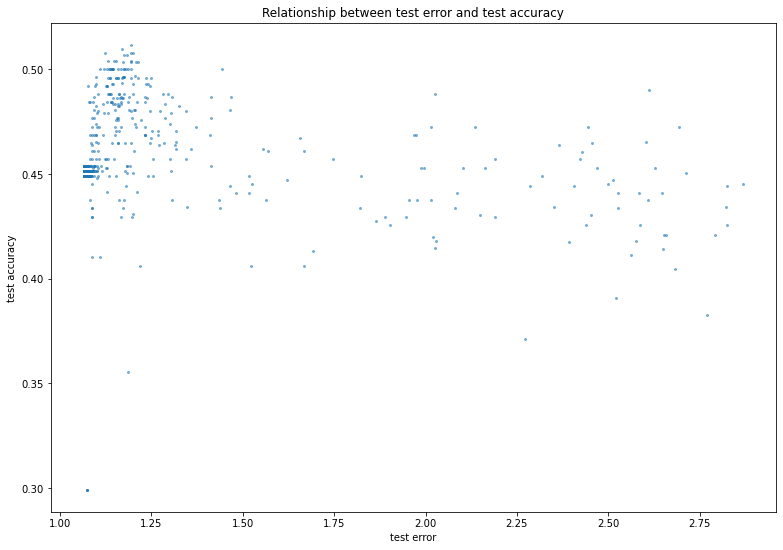

In [268]:
#   SCATTER PLOT - test_error vs test_acc
data_plot = df[df.error_test<3]
plt.figure(figsize=(13,9))
plt.title('Relationship between test error and test accuracy')
plt.scatter(x=data_plot.error_test,y=data_plot.acc_test, alpha=.5, s=4)
plt.xlabel('test error'); plt.ylabel('test accuracy')
# plt.savefig(path_summary + 'scatter_testerror_testacc' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

No existe una muy fuerte correlacion entre el error y el accuracy en el test. Lo que podria sugerir, que o bien la funcion de loss no es la optima o que el error no es la mejor metrica para medir el modelo.

Text(0, 0.5, 'train accuracy')

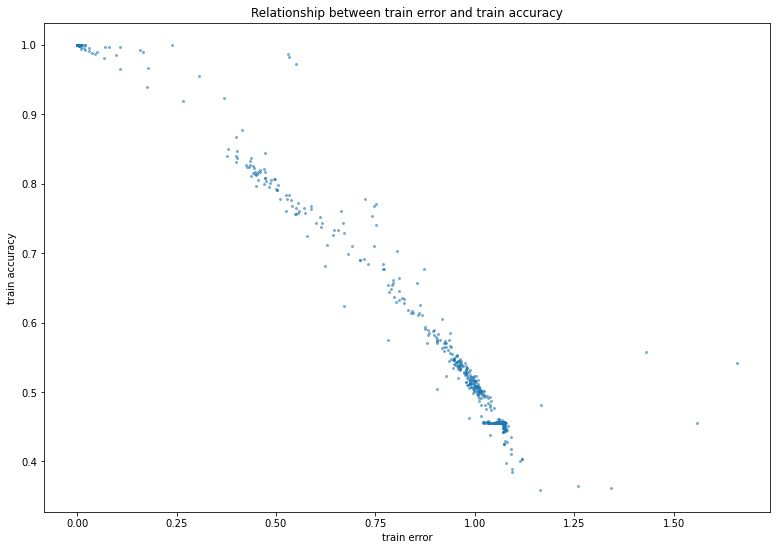

In [269]:
#   SCATTER PLOT - test_error vs test_acc
data_plot = df[df.error_train<3]
plt.figure(figsize=(13,9))
plt.title('Relationship between train error and train accuracy')
plt.scatter(x=data_plot.error_train,y=data_plot.acc_train, alpha=.5, s=4)
plt.xlabel('train error'); plt.ylabel('train accuracy')
# plt.savefig(path_summary + 'scatter_trainerror_trainacc' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

In [270]:
# 1-. ACABAR AUC-ROC
# 2-. Acabar de analizar los hiperparámetros óptimos
# 3-. Comprovar ejecuciones para Anova, featsel, PCA, variance threshold y nueva ejecucion lanzada...
# 4-. Lanzar experimentos de optimizacion de la arquitectura con muy poca optimizacion de hiperparámetros

### Other metrics

#### Precision Score

In [271]:
res[0]['cm']

[[15.0, 47.0, 13.0], [29.0, 86.0, 23.0], [17.0, 41.0, 33.0]]

In [272]:
np.sum([[1,2,3],[2,5,8]],axis=0)


array([ 3,  7, 11])

In [273]:
def precision_score(conf_matrix):
    conf_matrix = np.array(conf_matrix)
    tpfn = np.sum(conf_matrix,axis=1)
    tp = conf_matrix.diagonal()
    return tp/tpfn

def add_precision(df,jsons):
    if 'precision_draw' in df.columns: return df
    p0,p1,p2 = np.array([ precision_score(j['cm']) for j in jsons ]).T
    precisions = pd.DataFrame({
                                'precision_draw': p0,
                                'precision_home': p1,
                                'precision_away': p2
                             })
    return pd.concat([df,precisions],axis=1)

In [274]:
precision_score(res[0]['cm'])

array([0.2       , 0.62318841, 0.36263736])

In [275]:
df = add_precision(df,res)
df

,model,architecture,p,optimizer,momentum,weight_decay,nesterov,dampening,lr,b1,...,scaler,batch_size,epochs,error_train,error_test,acc_train,acc_test,precision_draw,precision_home,precision_away
0,NeuralNetworkDOClass,120_50_25,0.120553,SGD,0.891773,0.000000,0.0,0.000000,0.00100,NaN,...,basic,16,250,0.817060,1.516803,0.635110,0.440789,0.200000,0.623188,0.362637
1,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.10000,0.832620,...,MinMaxScaler,32,250,1.072742,1.089138,0.455882,0.451389,0.000000,1.000000,0.000000
2,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.832620,...,basic,64,250,0.905230,1.245437,0.576287,0.464844,0.112903,0.686957,0.417722
3,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.778157,...,Normalizer,16,250,0.883490,1.247529,0.584559,0.467105,0.173333,0.666667,0.406593
4,NeuralNetworkBNClass,120_50_25,0.000000,Adam,NaN,0.000000,NaN,NaN,0.00001,0.001000,...,basic,128,250,0.924791,1.127353,0.573242,0.453125,0.032258,0.765217,0.329114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NeuralNetworkDOClass,120_50_25,0.108977,Adam,NaN,0.000000,NaN,NaN,0.00010,0.001000,...,MaxAbsScaler,128,250,0.962390,1.161603,0.539062,0.488281,0.064516,0.756522,0.430380
996,NeuralNetworkDOClass,120_50_25,0.109763,SGD,0.963663,0.000000,0.0,0.043565,0.00010,NaN,...,MaxAbsScaler,16,250,1.000533,1.149259,0.516544,0.483553,0.000000,0.746377,0.483516
997,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.211827,NaN,NaN,0.00100,0.778157,...,StandardScaler,64,250,1.069350,1.070615,0.455882,0.449219,0.000000,1.000000,0.000000
998,NeuralNetworkDOClass,120_50_25,0.143038,SGD,0.891773,0.000000,0.0,0.462798,0.00010,NaN,...,MinMaxScaler,128,250,1.066114,1.067451,0.457031,0.449219,0.000000,1.000000,0.000000


#### Recall Score

In [276]:
def recall_score(conf_matrix):
    conf_matrix = np.array(conf_matrix)
    tpfn = np.sum(conf_matrix,axis=0)
    tp = conf_matrix.diagonal()
    recall = tp/tpfn
    recall = np.nan_to_num(recall)
    return recall

def add_recall(df,jsons):
    if 'recall_draw' in df.columns: return df
    p0,p1,p2 = np.array([ recall_score(j['cm']) for j in jsons ]).T
    recalls = pd.DataFrame({
                                'recall_draw': p0,
                                'recall_home': p1,
                                'recall_away': p2
                             })
    return pd.concat([df,recalls],axis=1)

In [277]:
print(res[1]['cm'])
recall_score(res[1]['cm'])

[[0.0, 70.0, 0.0], [0.0, 130.0, 0.0], [0.0, 88.0, 0.0]]


<ipython-input-276-11704a69149a>:5: RuntimeWarning: invalid value encountered in true_divide
  recall = tp/tpfn


array([0.        , 0.45138889, 0.        ])

In [278]:
df = add_recall(df,res)
df

<ipython-input-276-11704a69149a>:5: RuntimeWarning: invalid value encountered in true_divide
  recall = tp/tpfn


,model,architecture,p,optimizer,momentum,weight_decay,nesterov,dampening,lr,b1,...,error_train,error_test,acc_train,acc_test,precision_draw,precision_home,precision_away,recall_draw,recall_home,recall_away
0,NeuralNetworkDOClass,120_50_25,0.120553,SGD,0.891773,0.000000,0.0,0.000000,0.00100,NaN,...,0.817060,1.516803,0.635110,0.440789,0.200000,0.623188,0.362637,0.245902,0.494253,0.478261
1,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.10000,0.832620,...,1.072742,1.089138,0.455882,0.451389,0.000000,1.000000,0.000000,0.000000,0.451389,0.000000
2,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.832620,...,0.905230,1.245437,0.576287,0.464844,0.112903,0.686957,0.417722,0.241379,0.506410,0.464789
3,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.778157,...,0.883490,1.247529,0.584559,0.467105,0.173333,0.666667,0.406593,0.260000,0.505495,0.513889
4,NeuralNetworkBNClass,120_50_25,0.000000,Adam,NaN,0.000000,NaN,NaN,0.00001,0.001000,...,0.924791,1.127353,0.573242,0.453125,0.032258,0.765217,0.329114,0.117647,0.497175,0.419355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NeuralNetworkDOClass,120_50_25,0.108977,Adam,NaN,0.000000,NaN,NaN,0.00010,0.001000,...,0.962390,1.161603,0.539062,0.488281,0.064516,0.756522,0.430380,0.210526,0.533742,0.459459
996,NeuralNetworkDOClass,120_50_25,0.109763,SGD,0.963663,0.000000,0.0,0.043565,0.00010,NaN,...,1.000533,1.149259,0.516544,0.483553,0.000000,0.746377,0.483516,0.000000,0.502439,0.444444
997,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.211827,NaN,NaN,0.00100,0.778157,...,1.069350,1.070615,0.455882,0.449219,0.000000,1.000000,0.000000,0.000000,0.449219,0.000000
998,NeuralNetworkDOClass,120_50_25,0.143038,SGD,0.891773,0.000000,0.0,0.462798,0.00010,NaN,...,1.066114,1.067451,0.457031,0.449219,0.000000,1.000000,0.000000,0.000000,0.449219,0.000000


#### F-1 Score

In [4]:
def f1_score(conf_matrix):
    conf_matrix = np.array(conf_matrix)
    precision = (precision_score(conf_matrix))
    recall = recall_score(conf_matrix)
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

def add_f1score(df,jsons):
    if 'f1_draw' in df.columns: return df
    p0,p1,p2 = np.array([ f1_score(j['cm']) for j in jsons ]).T
    f1_scores = pd.DataFrame({
                                'f1_draw': p0,
                                'f1_home': p1,
                                'f1_away': p2
                             })
    return pd.concat([df,f1_scores.fillna(0)],axis=1)

In [280]:
f1_score(res[0]['cm'])

array([0.22058824, 0.55128205, 0.4125    ])

In [281]:
df = add_f1score(df,res)
df

<ipython-input-276-11704a69149a>:5: RuntimeWarning: invalid value encountered in true_divide
  recall = tp/tpfn


,model,architecture,p,optimizer,momentum,weight_decay,nesterov,dampening,lr,b1,...,acc_test,precision_draw,precision_home,precision_away,recall_draw,recall_home,recall_away,f1_draw,f1_home,f1_away
0,NeuralNetworkDOClass,120_50_25,0.120553,SGD,0.891773,0.000000,0.0,0.000000,0.00100,NaN,...,0.440789,0.200000,0.623188,0.362637,0.245902,0.494253,0.478261,0.220588,0.551282,0.412500
1,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.10000,0.832620,...,0.451389,0.000000,1.000000,0.000000,0.000000,0.451389,0.000000,0.000000,0.622010,0.000000
2,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.832620,...,0.464844,0.112903,0.686957,0.417722,0.241379,0.506410,0.464789,0.153846,0.583026,0.440000
3,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.778157,...,0.467105,0.173333,0.666667,0.406593,0.260000,0.505495,0.513889,0.208000,0.575000,0.453988
4,NeuralNetworkBNClass,120_50_25,0.000000,Adam,NaN,0.000000,NaN,NaN,0.00001,0.001000,...,0.453125,0.032258,0.765217,0.329114,0.117647,0.497175,0.419355,0.050633,0.602740,0.368794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NeuralNetworkDOClass,120_50_25,0.108977,Adam,NaN,0.000000,NaN,NaN,0.00010,0.001000,...,0.488281,0.064516,0.756522,0.430380,0.210526,0.533742,0.459459,0.098765,0.625899,0.444444
996,NeuralNetworkDOClass,120_50_25,0.109763,SGD,0.963663,0.000000,0.0,0.043565,0.00010,NaN,...,0.483553,0.000000,0.746377,0.483516,0.000000,0.502439,0.444444,0.000000,0.600583,0.463158
997,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.211827,NaN,NaN,0.00100,0.778157,...,0.449219,0.000000,1.000000,0.000000,0.000000,0.449219,0.000000,0.000000,0.619946,0.000000
998,NeuralNetworkDOClass,120_50_25,0.143038,SGD,0.891773,0.000000,0.0,0.462798,0.00010,NaN,...,0.449219,0.000000,1.000000,0.000000,0.000000,0.449219,0.000000,0.000000,0.619946,0.000000


In [298]:
cols = [ col for col in df.columns if ('precision' not in col and 'recall' not in col)]
df[cols]

,model,architecture,p,optimizer,momentum,weight_decay,nesterov,dampening,lr,b1,...,scaler,batch_size,epochs,error_train,error_test,acc_train,acc_test,f1_draw,f1_home,f1_away
0,NeuralNetworkDOClass,120_50_25,0.120553,SGD,0.891773,0.000000,0.0,0.000000,0.00100,NaN,...,basic,16,250,0.817060,1.516803,0.635110,0.440789,0.220588,0.551282,0.412500
1,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.10000,0.832620,...,MinMaxScaler,32,250,1.072742,1.089138,0.455882,0.451389,0.000000,0.622010,0.000000
2,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.832620,...,basic,64,250,0.905230,1.245437,0.576287,0.464844,0.153846,0.583026,0.440000
3,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.000000,NaN,NaN,0.00010,0.778157,...,Normalizer,16,250,0.883490,1.247529,0.584559,0.467105,0.208000,0.575000,0.453988
4,NeuralNetworkBNClass,120_50_25,0.000000,Adam,NaN,0.000000,NaN,NaN,0.00001,0.001000,...,basic,128,250,0.924791,1.127353,0.573242,0.453125,0.050633,0.602740,0.368794
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,NeuralNetworkDOClass,120_50_25,0.108977,Adam,NaN,0.000000,NaN,NaN,0.00010,0.001000,...,MaxAbsScaler,128,250,0.962390,1.161603,0.539062,0.488281,0.098765,0.625899,0.444444
996,NeuralNetworkDOClass,120_50_25,0.109763,SGD,0.963663,0.000000,0.0,0.043565,0.00010,NaN,...,MaxAbsScaler,16,250,1.000533,1.149259,0.516544,0.483553,0.000000,0.600583,0.463158
997,NeuralNetworkDOClass,120_50_25,0.120553,Adam,NaN,0.211827,NaN,NaN,0.00100,0.778157,...,StandardScaler,64,250,1.069350,1.070615,0.455882,0.449219,0.000000,0.619946,0.000000
998,NeuralNetworkDOClass,120_50_25,0.143038,SGD,0.891773,0.000000,0.0,0.462798,0.00010,NaN,...,MinMaxScaler,128,250,1.066114,1.067451,0.457031,0.449219,0.000000,0.619946,0.000000


#### AUC-ROC

NECESITAMOS LAS PREDICCIONES !!!!!

In [282]:
np.array(res[0]['cm'])

array([[15., 47., 13.],
       [29., 86., 23.],
       [17., 41., 33.]])

In [283]:
def fpr_score(conf_matrix,class_):
    conf_matrix = np.array(conf_matrix)
    tn = np.sum(np.delete(conf_matrix.diagonal(),class_))
    fp = np.sum(np.delete(conf_matrix[class_],class_))
    return fp / (tn + fp)

def aucroc_score(conf_matrix,class_):
    tpr = recall = recall_score(conf_matrix)[class_]
    fpr = fpr_score(conf_matrix,class_)
    return tpr,fpr

In [284]:
aucroc_score(res[0]['cm'],0)

(0.2459016393442623, 0.33519553072625696)

## WHAT'S THE BEST HYPERPARAMETER VALUE?

In [242]:
balanced = ''

In [271]:
remove_str = lambda x: np.nan if x=='' else x

def get_results(titles,extra_names=''):
    dfs = [ pd.read_excel(path_scores + f'{exec}.xlsx',sheet_name='CONFIGS',na_values='').drop('Unnamed: 0',axis=1) for exec in titles]
    exec = '__'.join(titles)
    for df in dfs:
        df['error_test'] = df.error_test.map(remove_str)
    if extra_names!='': 
        for i,e in enumerate(extra_names): 
            dfs[i]['dataset'] = e
    results = pd.concat(dfs,axis=0,ignore_index=True)
    return results,exec

In [272]:
results, exec = get_results(['rs_weights_wyscout'],['loss weights random search'])

In [273]:
[ i for i in results.error_test if isinstance(i,str)]

[]

In [274]:
exec = 'rs_weights_wyscout'

In [275]:
results

,confnum,model,architecture,numparams,activation,neg_slope,n_layers,p,optimizer,momentum,...,recall_draw,recall_home,recall_away,precision_draw,precision_home,precision_away,f1_draw,f1_home,f1_away,dataset
0,192,NeuralNetworkDOClass,7_22_22,898,leaky_relu,0.100,3,0.025852,SGD,0.705120,...,0.942857,0.038462,0.000000,0.238267,0.454545,0.000000,0.380403,0.070922,0.000000,loss weights random search
1,322,NeuralNetworkDOClass,3_3_49,421,leaky_relu,0.001,3,0.037032,SGD,0.705120,...,0.842857,0.130769,0.000000,0.232283,0.500000,0.000000,0.364198,0.207317,0.000000,loss weights random search
2,374,NeuralNetworkDOClass,9_3_8,278,leaky_relu,0.001,3,0.094953,Adam,NaN,...,1.000000,0.000000,0.000000,0.243056,0.000000,0.000000,0.391061,0.000000,0.000000,loss weights random search
3,294,NeuralNetworkDOClass,8_40_3,663,leaky_relu,0.100,3,0.054915,SGD,0.926482,...,1.000000,0.000000,0.000000,0.243056,0.000000,0.000000,0.391061,0.000000,0.000000,loss weights random search
4,255,NeuralNetworkBNClass,3_3_49,531,leaky_relu,0.001,3,0.000000,SGD,0.926482,...,0.000000,0.053846,0.954545,0.000000,0.500000,0.306569,0.000000,0.097222,0.464088,loss weights random search
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,335,NeuralNetworkDOClass,5_17_32,882,leaky_relu,0.100,3,0.090042,Adam,NaN,...,0.000000,0.669231,0.522727,0.000000,0.500000,0.403509,0.000000,0.572368,0.455446,loss weights random search
396,33,NeuralNetworkBNClass,73_53_21,6949,relu,NaN,3,0.000000,Adam,NaN,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.305556,0.000000,0.000000,0.468085,loss weights random search
397,334,NeuralNetworkDOClass,8_3_4,226,leaky_relu,0.001,3,0.151455,Adam,NaN,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.305556,0.000000,0.000000,0.468085,loss weights random search
398,29,NeuralNetworkDOClass,73_53_21,6655,leaky_relu,0.100,3,0.153511,Adam,NaN,...,1.000000,0.000000,0.000000,0.243056,0.000000,0.000000,0.391061,0.000000,0.000000,loss weights random search


In [276]:
results.dtypes

confnum             int64
model              object
architecture       object
numparams           int64
activation         object
neg_slope         float64
n_layers            int64
p                 float64
optimizer          object
momentum          float64
weight_decay      float64
nesterov          float64
dampening         float64
lr                float64
b1                float64
b2                float64
criterion          object
weight_draw       float64
weight_home       float64
weight_away       float64
scaler             object
batch_size          int64
epochs              int64
error_train       float64
error_test        float64
acc_train         float64
acc_test          float64
runtype            object
dims                int64
recall_draw       float64
recall_home       float64
recall_away       float64
precision_draw    float64
precision_home    float64
precision_away    float64
f1_draw           float64
f1_home           float64
f1_away           float64
dataset     

In [24]:
results = results.drop('factor',axis=1).drop_duplicates()

KeyError: "['factor'] not found in axis"

In [11]:
results.factor.unique()

AttributeError: 'DataFrame' object has no attribute 'factor'

In [277]:
def join_loss_weights(x):
    if 'weight_away' in x.index:
        return '_'.join([str(x['weight_draw']),str(x['weight_home']),str(x['weight_away'])])
    else:
        return '_'.join([str(x['weight_draw']),str(x['weight_home'])])

In [19]:
# RESULTS WITH POSITIVE PRECISION IN EVERY CLASS
balanced = '_bal'
flag_precision_home = results.precision_home > 0
flag_precision_draw = results.precision_draw > 0
flag_precision_away = results.precision_away > 0
flag_mask = flag_precision_home & flag_precision_draw & flag_precision_away
results = results[flag_mask]
results


,confnum,model,architecture,numparams,activation,neg_slope,n_layers,p,optimizer,momentum,...,precision_draw,precision_home,precision_away,recall_draw,recall_home,recall_away,f1_draw,f1_home,f1_away,dataset
6,79,NeuralNetworkBNClass,7_6_83,2060,leaky_relu,0.001,3,0.000000,SGD,0.202936,...,0.315789,0.524742,0.515775,0.006772,0.890351,0.386037,0.013260,0.660316,0.441574,hist_longterm
14,62,dumbmodelclass,7_6_18,588,relu,NaN,3,0.000000,SGD,0.983749,...,0.200000,0.535228,0.477765,0.002257,0.861529,0.430185,0.004464,0.660264,0.452728,hist_longterm
21,77,dumbmodelclass,5_21_7,434,leaky_relu,0.100,3,0.000000,Adam,NaN,...,0.500000,0.546444,0.456767,0.001129,0.818296,0.498973,0.002252,0.655294,0.476938,hist_longterm
27,98,NeuralNetworkDOClass,7_6_18,588,relu,NaN,3,0.028418,Adam,NaN,...,0.666667,0.541176,0.462551,0.002257,0.835840,0.469199,0.004499,0.656981,0.465851,hist_longterm
45,0,NeuralNetworkDOClass,7_8_68,1870,leaky_relu,0.010,3,0.014616,Adam,NaN,...,0.285714,0.555066,0.447837,0.002257,0.789474,0.542094,0.004479,0.651837,0.490478,hist_longterm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2785,55,dumbmodelclass,14_15_9,763,leaky_relu,0.010,3,0.000000,Adam,NaN,...,1.000000,0.538462,0.264656,0.001629,0.006200,0.996800,0.003252,0.012259,0.418261,hist_goals_longterm
2789,65,dumbmodelclass,6_44_6,755,leaky_relu,0.001,3,0.000000,SGD,0.372656,...,0.259018,1.000000,0.454545,0.970684,0.000886,0.048000,0.408919,0.001770,0.086831,hist_goals_longterm
2840,65,dumbmodelclass,6_44_6,1085,leaky_relu,0.001,3,0.000000,SGD,0.372656,...,0.261094,0.777778,0.103448,0.986971,0.012400,0.004800,0.412947,0.024412,0.009174,hist_goals_longterm
2845,0,NeuralNetworkDOClass,7_8_68,1450,leaky_relu,0.010,3,0.014616,Adam,NaN,...,0.259746,1.000000,0.333333,0.998371,0.004429,0.001600,0.412239,0.008818,0.003185,hist_goals_longterm


In [278]:
results['loss_weights'] = results.apply(join_loss_weights,axis=1)

In [279]:
results.columns

Index(['confnum', 'model', 'architecture', 'numparams', 'activation',
       'neg_slope', 'n_layers', 'p', 'optimizer', 'momentum', 'weight_decay',
       'nesterov', 'dampening', 'lr', 'b1', 'b2', 'criterion', 'weight_draw',
       'weight_home', 'weight_away', 'scaler', 'batch_size', 'epochs',
       'error_train', 'error_test', 'acc_train', 'acc_test', 'runtype', 'dims',
       'recall_draw', 'recall_home', 'recall_away', 'precision_draw',
       'precision_home', 'precision_away', 'f1_draw', 'f1_home', 'f1_away',
       'dataset', 'loss_weights'],
      dtype='object')

In [280]:
cols = ['model','p',  'optimizer', 'weight_decay', 'dampening','momentum',
         'nesterov', 'lr', 'b1', 'b2','scaler', 'batch_size',#'weight_draw','weight_home','weight_away',
        'epochs','runtype','dims'] # 'n_layers','loss_weights','runtype','dims','dataset', 'neg_slope','activation','numparams'

cols = ['weight_draw','weight_home','weight_away']

In [281]:
# results = results[results["runtype"]=="basic"]
results['lr'] = results.lr.map(str)
results['n_layers'] = results.architecture.map(lambda x: len(x.split('_')))
results = results.round(3)
results[cols]

,weight_draw,weight_home,weight_away
0,1.65,0.56,0.13
1,1.65,0.56,0.13
2,1.65,0.56,0.13
3,1.65,0.56,0.13
4,0.41,0.37,1.42
...,...,...,...
395,3.57,2.72,1.80
396,2.21,0.13,3.88
397,3.93,1.49,1.68
398,2.64,2.13,0.92


In [282]:
results.error_test.describe()

count      399.000000
mean       122.425068
std       2403.830396
min          0.586000
25%          1.536000
50%          2.014000
75%          2.462500
max      48018.549000
Name: error_test, dtype: float64

1.145141333341599
dims 20


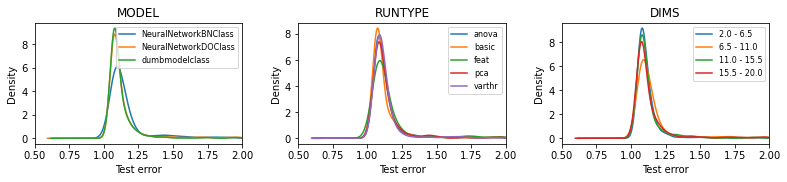

In [268]:
data_plot = results#[flag_mask]
print(data_plot.error_test[0])
data_plot = data_plot[data_plot.error_test<=2]  # hay ~10 outliers con error > 3
fig = plt.figure(figsize=(22,9))
att2plot = 'error_test'

for i,c in enumerate(cols):
    ax = fig.add_subplot(4,6,i+1)
    plots = sorted(data_plot[c].unique())
    nplots = len(plots)
    if nplots > 6: 
        print(c,max(plots))
        q = np.linspace(min(plots),max(plots)+.001,5)
        for j in range(len(q)-1):
            q1 = q[j+1]
            q2 = q[j]
            if q1==q2: print(c,q1,q2)
            data = data_plot[(data_plot[c]<q1) & (data_plot[c]>=q2)]
            if len(data)>1: data[att2plot].plot(kind='kde',label=f'{q2.round(2)} - {q1.round(2)}')
    else: 
        for plot in plots:
            data = data_plot[data_plot[c]==plot]
            if len(data)>1: data[att2plot].dropna().plot(kind='kde',label=plot)
    ax.legend(prop={'size': 8})
    ax.set_title(c.upper())
    ax.set_xlabel('Test error')
    ax.set_xlim(.5,2)

plt.tight_layout()
    
# plt.savefig(path_summary + f'{exec}_err{balanced}' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

weight_draw 3.93
weight_home 3.94


LinAlgError: singular matrix

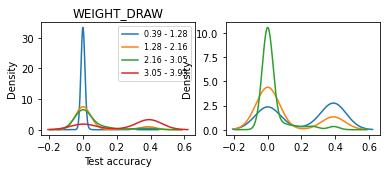

In [290]:
data_plot = results#[flag_mask]
# acc_thr = .46
# data_plot = data_plot[data_plot.acc_test>acc_thr]
fig = plt.figure(figsize=(16,12))
att2plot = 'f1_draw'

for i,c in enumerate(cols):
    ax = fig.add_subplot(5,5,i+1)
    plots = sorted(data_plot[c].dropna().unique())
    nplots = len(plots)
    if nplots > 5: 
        print(c,max(plots))
        q = np.linspace(min(plots),max(plots)+.001,5)
        for j in range(len(q)-1):
            q1 = q[j+1]
            q2 = q[j]
            if q1==q2: print(c,q1,q2)
            data = data_plot[(data_plot[c]<q1) & (data_plot[c]>=q2)]
            if len(data)>1: data[att2plot].plot(kind='kde',label=f'{q2.round(2)} - {q1.round(2)}')
    else: 
        for plot in plots:
            data = data_plot[data_plot[c]==plot]
            if len(data)>1: data[att2plot].dropna().plot(kind='kde',label=plot)
    ax.legend(prop={'size': 8})
    ax.set_title(c.upper())
    ax.set_xlabel('Test accuracy')
    # ax.set_xlim(0.1,.55)

plt.tight_layout()
    
plt.savefig(path_summary + f'{exec}_acc{balanced}' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

p 0.1873503216501327
numparams 13817


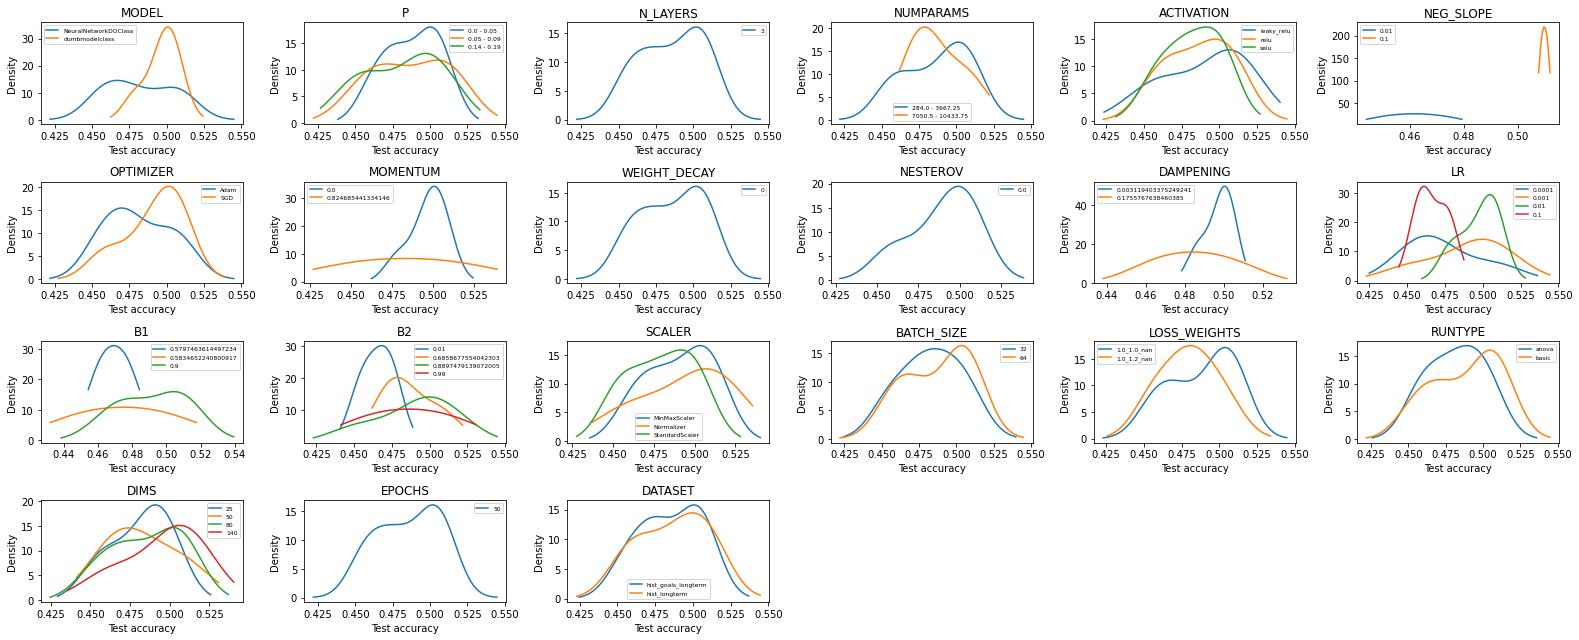

In [84]:
data_plot = results#[flag_mask]
acc_thr = .45
data_plot = data_plot[data_plot.acc_test>acc_thr]
fig = plt.figure(figsize=(22,9))
att2plot = 'acc_test'

for i,c in enumerate(cols):
    ax = fig.add_subplot(4,6,i+1)
    plots = sorted(data_plot[c].dropna().unique())
    nplots = len(plots)
    if nplots > 6: 
        print(c,max(plots))
        q = np.linspace(min(plots),max(plots)+.001,5)
        for j in range(len(q)-1):
            q1 = q[j+1]
            q2 = q[j]
            if q1==q2: print(c,q1,q2)
            data = data_plot[(data_plot[c]<q1) & (data_plot[c]>=q2)]
            if len(data)>1: data[att2plot].plot(kind='kde',label=f'{q2.round(2)} - {q1.round(2)}')
    else: 
        for plot in plots:
            data = data_plot[data_plot[c]==plot]
            if len(data)>1: data[att2plot].dropna().plot(kind='kde',label=plot)
    ax.legend(prop={'size': 6})
    ax.set_title(c.upper())
    ax.set_xlabel('Test accuracy')

plt.tight_layout()
    
plt.savefig(path_summary + f'{exec}_acc{acc_thr}{balanced}' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

weight_draw 3.93
weight_home 3.94


LinAlgError: singular matrix

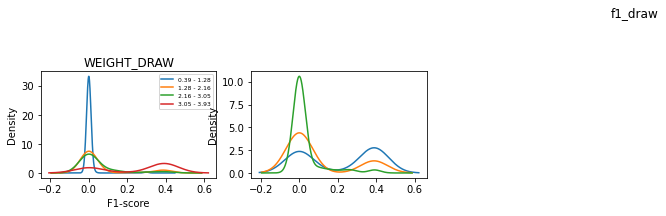

In [286]:
# EXTRA PLOT
data_plot = results#[flag_mask]
# data_plot = data_plot[data_plot.f1_draw>.1]  # hay ~10 outliers con error > 3
fig = plt.figure(figsize=(22,9))
att2plot = 'f1_draw'
fig.suptitle(att2plot)
for i,c in enumerate(cols):
    ax = fig.add_subplot(4,6,i+1)
    plots = sorted(data_plot[c].unique())
    nplots = len(plots)
    if nplots > 6: 
        print(c,max(plots))
        q = np.linspace(min(plots),max(plots)+.001,5)
        for j in range(len(q)-1):
            q1 = q[j+1]
            q2 = q[j]
            if q1==q2: print(c,q1,q2)
            data = data_plot[(data_plot[c]<q1) & (data_plot[c]>=q2)]
            if len(data)>1: data[att2plot].plot(kind='kde',label=f'{q2.round(2)} - {q1.round(2)}')
    else: 
        for plot in plots:
            data = data_plot[data_plot[c]==plot]
            if len(data)>1: data[att2plot].dropna().plot(kind='kde',label=plot)
    ax.legend(prop={'size': 6})
    ax.set_title(c.upper())
    ax.set_xlabel('F1-score')

plt.tight_layout()
    
plt.savefig(path_summary + f'{exec}_{att2plot}{balanced}' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

In [47]:
# plt.figure(figsize=(16,7))
data_plot = results[flag_mask]
plt.scatter(x=data_plot.f1_home,y=data_plot.f1_draw,alpha=.3,s=5)
plt.ylabel('f1 draw'); plt.xlabel('f1 home')

NameError: name 'flag_mask' is not defined

# CHECK RESULTS

In [95]:
def get_embed(y):
    dif = f(y[:,0]) - f(y[:,1])
    res = np.zeros(len(y))
    res[dif==0] = 0
    res[dif>0]  = 1
    res[dif<0]  = 2
    return res

In [43]:
# path_experiments = 'F://TFG//experiments//'
# path_outputs = "F://TFG//results//outputs//lightgbm//"
save=False
title = 'rs_histlong_basic_4_historical_longterm_117'
m62 = pd.read_csv(path_outputs+f'{title}.csv',sep=';',decimal=',').drop('Unnamed: 0',axis=1,errors='ignore')
# m62 = m62[(m62.epoch==49) & (m62['mode']==1) & (m62['config.']==62)]

# title = 'bets'
# m117 = pd.read_csv(path_outputs+f'{title}.csv',sep=';',decimal=',').drop('Unnamed: 0',axis=1,errors='ignore')
# # m117 = m117[(m117.epoch==99) & (m117['mode']==1) & (m117['config.']==137)]

In [44]:
outputs = m62
outputs['matchId'] = outputs.matchId.astype(int)
outputs

,matchId,draw_pred,home_pred,away_pred,prediction,label,config.,mode,epoch,HomeTeam,AwayTeam,FTR,FTHG,FTAG
0,559,0.282552,0.426411,0.291037,1.0,2.0,117.0,1.0,0.0,Aston Villa,Liverpool,2,1.0,2.0
1,564,0.225306,0.467503,0.307191,1.0,1.0,117.0,1.0,0.0,Ipswich,Leicester,1,2.0,0.0
2,586,0.246817,0.400903,0.352280,1.0,1.0,117.0,1.0,0.0,Man United,Newcastle,1,3.0,1.0
3,609,0.300945,0.390405,0.308650,1.0,2.0,117.0,1.0,0.0,Leicester,Arsenal,2,1.0,3.0
4,636,0.269982,0.434596,0.295422,1.0,1.0,117.0,1.0,0.0,Newcastle,Southampton,1,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35611,48290,0.008869,0.991075,0.000056,1.0,1.0,115.0,1.0,44.0,Rennes,Dijon,1,5.0,1.0
35612,48296,0.483928,0.207518,0.308553,0.0,1.0,115.0,1.0,44.0,Lille,Nice,1,2.0,0.0
35613,48298,0.149963,0.532526,0.317511,1.0,2.0,115.0,1.0,44.0,Brest,Nantes,2,1.0,4.0
35614,48299,0.440437,0.292497,0.267066,0.0,2.0,115.0,1.0,44.0,Dijon,Metz,2,1.0,5.0


In [456]:
m117.shape, m62.shape
m62

,matchId,draw_pred,home_pred,away_pred,prediction,label,config.,mode,epoch,HomeTeam,AwayTeam,FTR,FTHG,FTAG
16960,559.0,0.251802,0.350095,0.398103,2.0,2.0,117.0,1.0,99.0,Aston Villa,Liverpool,2,1.0,2.0
16961,564.0,0.236576,0.580877,0.182548,1.0,1.0,117.0,1.0,99.0,Ipswich,Leicester,1,2.0,0.0
16962,586.0,0.226111,0.506735,0.267154,1.0,1.0,117.0,1.0,99.0,Man United,Newcastle,1,3.0,1.0
16963,609.0,0.255992,0.218872,0.525136,2.0,2.0,117.0,1.0,99.0,Leicester,Arsenal,2,1.0,3.0
16964,636.0,0.253546,0.540428,0.206026,1.0,1.0,117.0,1.0,99.0,Newcastle,Southampton,1,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18651,48290.0,0.246824,0.597990,0.155186,1.0,1.0,117.0,1.0,99.0,Rennes,Dijon,1,5.0,1.0
18652,48296.0,0.289350,0.545315,0.165336,1.0,1.0,117.0,1.0,99.0,Lille,Nice,1,2.0,0.0
18653,48298.0,0.298630,0.453248,0.248122,1.0,2.0,117.0,1.0,99.0,Brest,Nantes,2,1.0,4.0
18654,48299.0,0.361449,0.356791,0.281760,0.0,2.0,117.0,1.0,99.0,Dijon,Metz,2,1.0,5.0


In [447]:
def cols2softmax(data,cols):
    preds = torch.tensor(data[cols].to_numpy())
    data[cols] = torch.softmax(preds,dim=1).numpy()
    return data

m117 = cols2softmax(m117,["draw_pred","home_pred","away_pred"])
# m62 = cols2softmax(m62,["draw_pred","home_pred","away_pred"])

In [620]:
cols = ["draw_pred","home_pred","away_pred","prediction"]
m117 = m117.set_index('matchId')[cols].add_suffix("_117")
m62 = m62.set_index('matchId')[cols].add_suffix("_62")

outputs = m117.join(m62,how='inner')
outputs
del(m62)
del(m117)

In [621]:
path_train      = 'F:\\TFG\\datasets\\raw_datasets\\'
raw_Data  = pd.read_csv(path_train+'historical_longterm'+'.csv',sep=';',decimal=',',index_col='matchId')#.set_index('wyId')

# cols = ['HomeTeam',
# 'AwayTeam',
# 'Date'
# 'FTR',
# 'FTHG',
# 'FTAG',
# 'aux'
# ]

cols = ['FTR',
'FTHG',
'FTAG',
'aux'
]

raw_Data = raw_Data.drop(cols,axis=1,errors='ignore')
raw_Data.sort_index()

raw_Data['year'] = raw_Data.Date.map(lambda x: (datetime.datetime.strptime(x,"%Y-%m-%d")).year)

In [622]:
outputs_data = outputs.merge(raw_Data,left_on='matchId',right_index=True,how='left').dropna()
outputs_data

,draw_pred_117,home_pred_117,away_pred_117,prediction_117,draw_pred_62,home_pred_62,away_pred_62,prediction_62,Div,Date,...,Scored_1825D_away,Received_1825D_away,points_1825D_away,Shots_1825D_away,Target_1825D_away,Corner_1825D_away,Faults_1825D_away,YellowCards_1825D_away,RedCards_1825D_away,year
matchId,,,,,,,,,,,,,,,,,,,,,
23201.0,0.263158,0.181818,0.621118,2,0.325543,0.243339,0.431118,2.0,D1,2007-12-15,...,86.0,48.0,1.900000,17.660000,8.960000,6.420000,16.240000,1.560000,0.620000,2007
23203.0,0.250000,0.666667,0.148148,1,0.282467,0.548449,0.169085,1.0,D1,2007-12-15,...,63.0,58.0,1.260000,14.760000,6.920000,4.860000,18.000000,1.920000,0.900000,2007
23254.0,0.294118,0.266667,0.500000,2,0.325551,0.243381,0.431068,2.0,D1,2008-03-08,...,87.0,56.0,1.839286,15.660714,7.375000,6.089286,18.785714,1.928571,0.803571,2008
23263.0,0.303030,0.322581,0.434783,2,0.325550,0.243398,0.431052,2.0,D1,2008-03-15,...,100.0,75.0,1.877193,16.228070,7.894737,5.701754,18.017544,1.666667,0.842105,2008
23269.0,0.266667,0.621118,0.181818,1,0.286450,0.550438,0.163112,1.0,D1,2008-03-16,...,67.0,68.0,1.157895,14.684211,6.508772,4.719298,17.982456,1.947368,0.929825,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18270.0,0.250000,0.636943,0.173913,1,0.301504,0.510598,0.187898,1.0,SP1,2021-05-03,...,222.0,212.0,1.368984,11.192513,4.016043,4.978610,13.871658,2.508021,1.288770,2021
18279.0,0.266667,0.526316,0.266667,1,0.299500,0.521236,0.179264,1.0,SP1,2021-05-09,...,284.0,218.0,1.759358,13.112299,4.652406,5.449198,14.229947,2.641711,1.331551,2021
18289.0,0.307692,0.357143,0.392157,2,0.358729,0.306767,0.334504,0.0,SP1,2021-05-13,...,240.0,285.0,1.313830,11.691489,4.250000,4.553191,12.952128,2.531915,1.303191,2021


In [18]:
mask = (outputs_data.points_60D_home>1.8) & (outputs_data.points_60D_away<=2) & (outputs_data.points_1825D_home<1.5) & (outputs_data.points_1825D_away>1.5)
outputs_data[mask][['HomeTeam','AwayTeam','HTHG','HTAG','points_15D_home','points_15D_away','points_60D_home','points_60D_away','points_1825D_home','points_1825D_away']]

,HomeTeam,AwayTeam,HTHG,HTAG,points_15D_home,points_15D_away,points_60D_home,points_60D_away,points_1825D_home,points_1825D_away
matchId,,,,,,,,,,
1400.0,Blackburn,Arsenal,1.0,0.0,1.500000,0.500000,2.000000,1.333333,1.431373,2.017857
1726.0,Tottenham,Liverpool,0.0,1.0,2.000000,2.000000,1.900000,2.000000,1.473684,1.939130
1970.0,Man City,Newcastle,1.0,1.0,2.000000,1.500000,1.857143,1.833333,1.247788,1.513274
2653.0,Fulham,Everton,0.0,1.0,3.000000,2.000000,1.857143,1.714286,1.165563,1.543046
3155.0,Man City,Man United,0.0,0.0,1.500000,3.000000,2.000000,2.000000,1.359788,2.294737
5057.0,West Ham,Everton,1.0,1.0,1.500000,1.500000,2.000000,1.571429,1.177632,1.547368
6911.0,Everton,Man United,1.0,2.0,0.000000,0.500000,1.857143,1.166667,1.383784,1.798913
6916.0,Leicester,Wolves,1.0,0.0,3.000000,2.000000,2.142857,1.857143,1.491892,1.554217
12821.0,Betis,Sevilla,0.0,0.0,3.000000,2.000000,2.000000,1.571429,1.118644,1.864407


In [24]:
mask = 15462
outputs_data.loc[mask][['HomeTeam','AwayTeam','HTHG','HTAG','points_15D_home','points_15D_away','points_60D_home','points_60D_away','points_1825D_home','points_1825D_away']]

HomeTeam                   Betis
AwayTeam             Real Madrid
HTHG                         0.0
HTAG                         3.0
points_15D_home              0.5
points_15D_away              3.0
points_60D_home         0.333333
points_60D_away         2.666667
points_1825D_home       1.184211
points_1825D_away       2.421053
Name: 15462.0, dtype: object

In [15]:
pred_draws = outputs_data[['home_pred_117','home_pred_62']]
pred_draws

,home_pred_117,home_pred_62
matchId,,
155.0,0.550164,0.620641
183.0,0.412883,0.496609
191.0,0.215609,0.332071
195.0,0.105500,0.170596
196.0,0.267810,0.337747
...,...,...
2576154.0,0.044646,0.079326
2576179.0,0.562999,0.606999
2576182.0,0.573326,0.620641


In [526]:
outputs_data.columns[25:]

Index(['HR', 'AR', 'season', 'IdH', 'IdA', 'side_avg_15D_home',
       'Scored_15D_home', 'Received_15D_home', 'points_15D_home',
       'Shots_15D_home',
       ...
       'side_avg_1825D_away', 'Scored_1825D_away', 'Received_1825D_away',
       'points_1825D_away', 'Shots_1825D_away', 'Target_1825D_away',
       'Corner_1825D_away', 'Faults_1825D_away', 'YellowCards_1825D_away',
       'RedCards_1825D_away'],
      dtype='object', length=145)

In [623]:
# outputs_data.columns = sorted(outputs_data.columns)
outputs_data.round(4).to_csv(path_outputs + "bets_vs_f1.csv",sep=';',decimal=',')

In [20]:
del(pred_draws)

In [92]:
np.bincount(outputs_data.label)/len(outputs_data), np.bincount(outputs_data.prediction)/len(outputs_data)

(array([0.7181713, 0.2818287]), array([0.7103588, 0.2896412]))

In [172]:
outputs_data.prediction.unique()

array([1., 2., 0.])

##### Clustering

In [389]:
col_home, col_away = 'points_1825D_home', 'points_365D_home'
top1825_home = outputs_data.groupby('HomeTeam').agg({col_home:'mean'})
top1825_away = outputs_data.groupby('HomeTeam').agg({col_away:'mean', 'Div':'first'})
# top1825_home = outputs_data.groupby(['HomeTeam','year']).agg({col_home:'mean'})
# top1825_away = outputs_data.groupby(['HomeTeam','year']).agg({col_away:'mean', 'Div':'first'})

# top1825_home.sort_values(col_home), top1825_away.sort_values(col_away)

In [390]:
top1825 = top1825_home.merge(top1825_away,right_index=True,left_index=True)
top1825

,points_1825D_home,points_365D_home,Div
HomeTeam,,,
Aachen,1.200000,1.200000,D1
Ajaccio,0.997462,0.812064,F1
Ajaccio GFCO,1.098767,1.098767,F1
Alaves,1.253913,1.178415,SP1
Almeria,1.157464,1.094766,SP1
...,...,...,...
Wigan,1.177912,1.018885,E0
Wolfsburg,1.436077,1.386902,D1
Wolves,1.231959,1.205733,E0


In [391]:
top1825.columns

Index(['points_1825D_home', 'points_365D_home', 'Div'], dtype='object')

In [392]:
import plotly.express as plotly
top1825 = top1825.reset_index()
plotly.scatter(top1825,col_home,col_away,hover_name='HomeTeam',color='Div',width=1200,height=700)

In [393]:
from sklearn.cluster import KMeans
import random

In [394]:
random.seed(0)
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit(top1825[[col_home,col_away]].pow(3))
order = np.argsort(np.argsort(clusters.cluster_centers_[:,0]))
print(clusters.cluster_centers_[:,0],order,clusters.labels_)
top1825['cluster'] = clusters.labels_
map_ = {c:str(order[c]) for c in top1825.cluster}
print(map_)
top1825['cluster'] = top1825['cluster'].map(map_)
# top1825 = top1825.reset_index()


c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\sklearn\cluster\_kmeans.py:1332: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



[1.49179654 5.15256702 9.83688949] [0 1 2] [0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 2 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0
 1 0 0 0 0 1 2 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 2 0
 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 0 0]
{0: '0', 1: '1', 2: '2'}


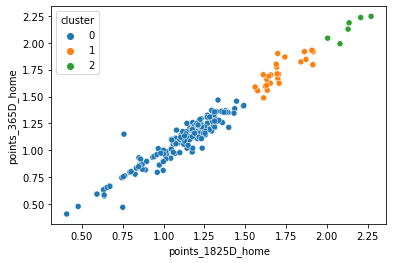

In [395]:
sns.scatterplot(data=top1825.sort_values("cluster"),x=col_home,y=col_away,hue='cluster')
plt.savefig(path_summary + f'scatter_cluster_{title}.jpg', format='jpg', dpi=200,bbox_inches='tight')
plotly.scatter(top1825,col_home,col_away,hover_name='HomeTeam',color='cluster',width=1200,height=700)

In [396]:
top1825 = top1825.set_index('HomeTeam').cluster.to_dict()
top1825
# top1825 = top1825.cluster.to_dict()

{'Aachen': '0',
 'Ajaccio': '0',
 'Ajaccio GFCO': '0',
 'Alaves': '0',
 'Almeria': '0',
 'Amiens': '0',
 'Angers': '0',
 'Arles': '0',
 'Arsenal': '1',
 'Ascoli': '0',
 'Aston Villa': '0',
 'Atalanta': '0',
 'Ath Bilbao': '0',
 'Ath Madrid': '1',
 'Augsburg': '0',
 'Auxerre': '0',
 'Barcelona': '2',
 'Bari': '0',
 'Bastia': '0',
 'Bayern Munich': '2',
 'Benevento': '0',
 'Betis': '0',
 'Bielefeld': '0',
 'Birmingham': '0',
 'Blackburn': '0',
 'Blackpool': '0',
 'Bochum': '0',
 'Bologna': '0',
 'Bolton': '0',
 'Bordeaux': '1',
 'Boulogne': '0',
 'Bournemouth': '0',
 'Bradford': '0',
 'Braunschweig': '0',
 'Brescia': '0',
 'Brest': '0',
 'Brighton': '0',
 'Burnley': '0',
 'Cadiz': '0',
 'Caen': '0',
 'Cagliari': '0',
 'Cardiff': '0',
 'Carpi': '0',
 'Catania': '0',
 'Celta': '0',
 'Cesena': '0',
 'Charlton': '0',
 'Chelsea': '2',
 'Chievo': '0',
 'Cordoba': '0',
 'Cottbus': '0',
 'Coventry': '0',
 'Crotone': '0',
 'Crystal Palace': '0',
 'Darmstadt': '0',
 'Derby': '0',
 'Dijon': '0',
 '

In [397]:
# outputs_data['cluster_home'] = outputs_data.apply(lambda r: top1825[(r['HomeTeam'],r['year'])]).fillna(0).astype(int)
# outputs_data['cluster_away'] = outputs_data.apply(lambda r: top1825[(r['AwayTeam'],r['year'])]).fillna(0).astype(int)
outputs_data['cluster_home'] = outputs_data['HomeTeam'].map(top1825).fillna(0).astype(int)
outputs_data['cluster_away'] = outputs_data['AwayTeam'].map(top1825).fillna(0).astype(int)
outputs_data['match_cluster'] = (outputs_data.cluster_home - outputs_data.cluster_away)

In [332]:
outputs_data[['draw_pred','home_pred','away_pred','HomeTeam','AwayTeam','prediction','label','FTR','cluster_home','cluster_away','match_cluster']]

KeyError: "['FTR'] not in index"

In [251]:
outputs_data['isaccurate'] = outputs_data.prediction==outputs_data.label

AttributeError: 'DataFrame' object has no attribute 'prediction'

In [184]:
#  QUE PASA EN LA REALIDAD - Como se distribuyen los resultados a lo largo de los clusters
outputs_data.groupby(['match_cluster','label']).isaccurate.count().to_frame()

isaccurate
match_cluster label            
-2            0.0            15
              1.0            13
              2.0            45
-1            0.0           245
              1.0           250
              2.0           391
 0            0.0           444
              1.0           714
              2.0           426
 1            0.0           172
              1.0           569
              2.0           103
 2            0.0            10
              1.0            50
              2.0             9

##### Type of match accuracy

In [74]:
# ACCURACY (per type of match)
outputs_data.groupby(['match_cluster']).agg({'isaccurate':['mean','count']}) #    .isaccurate.mean().to_frame()

isaccurate      
                    mean count
match_cluster                 
-2              0.608939   179
-1              0.432268   657
 0              0.433555  1806
 1              0.661417   635
 2              0.782123   179

In [122]:
import seaborn as sn
from sklearn.metrics import confusion_matrix

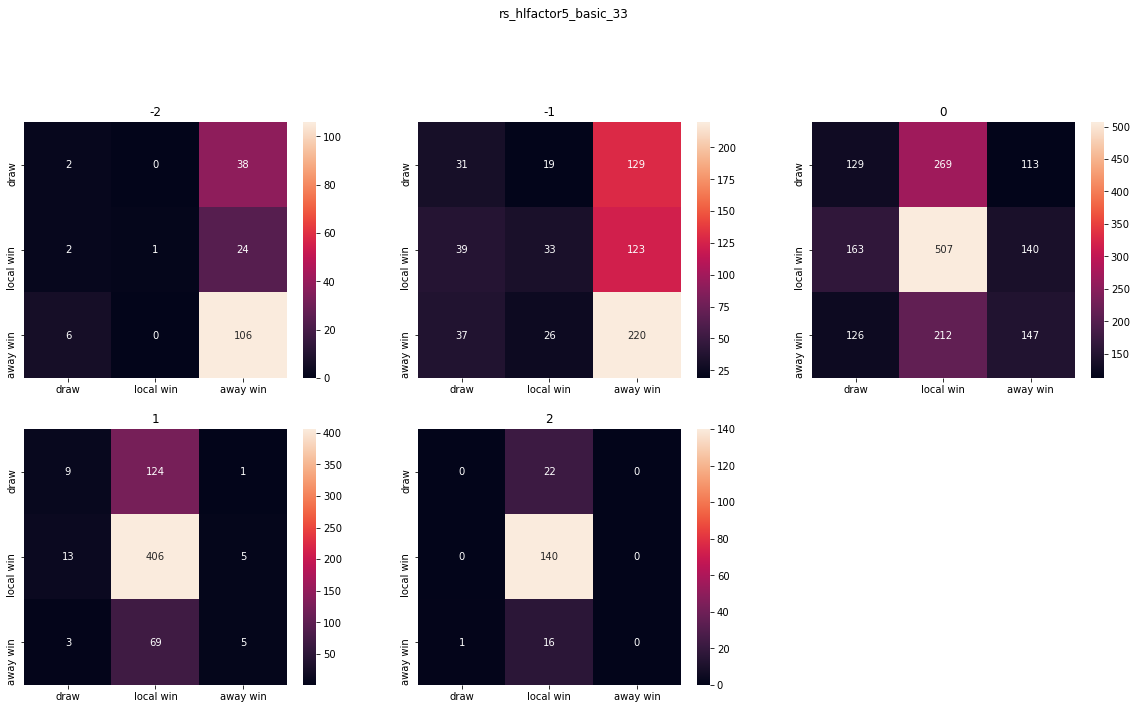

In [76]:
f = plt.figure(0)
f.set_size_inches(20,16)
f.suptitle(title)
for i,m in enumerate([-2,-1,0,1,2]):
    ax = f.add_subplot(3,3,i+1)
    conf_data = outputs_data[outputs_data.match_cluster==m]
    df_confmat = confusion_matrix(conf_data.label,conf_data.prediction,labels=[0,1,2])
    df_confmat = pd.DataFrame(df_confmat, index=['draw','local win','away win'], columns=['draw','local win','away win'])
    sn.heatmap(df_confmat,annot=True,fmt=".0f")
    ax.set_title(m)

##### Competition accuracy


In [386]:
outputs_data['isaccurate'] = outputs_data.prediction==outputs_data.label

In [285]:
acc_div = outputs_data.groupby(['Div']).agg({'isaccurate':['mean','count']}) #    .isaccurate.mean().to_frame()
acc_div

isaccurate      
          mean count
Div                 
D1    0.539806   515
E0    0.573554   605
F1    0.474359   468
I1    0.529022   603
SP1   0.527246   679

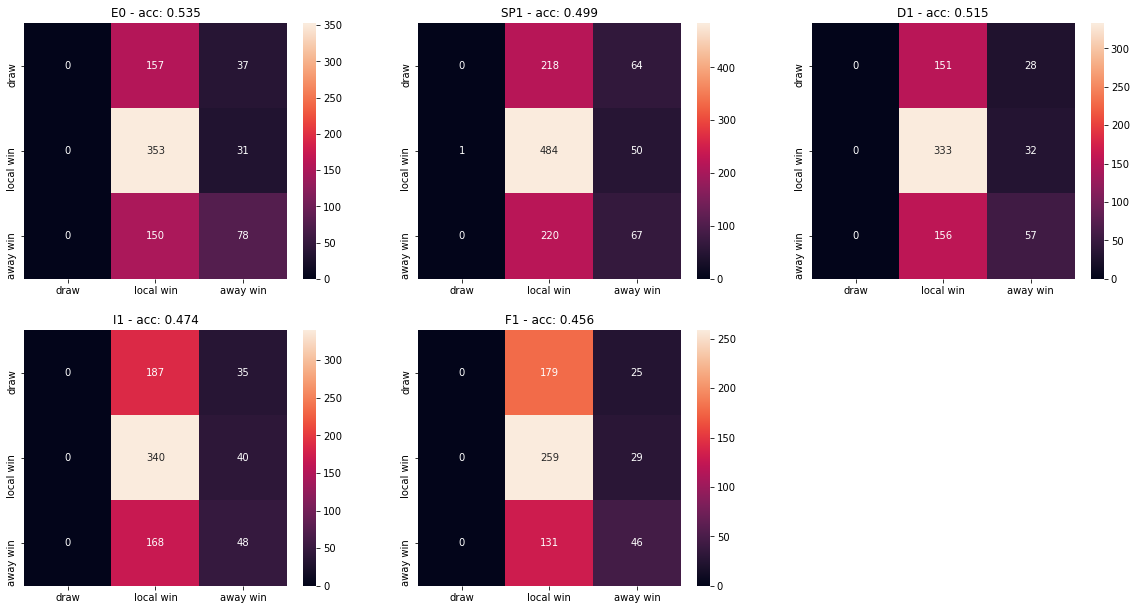

In [220]:
f = plt.figure(0)
f.set_size_inches(20,16)
# f.suptitle(title)

for i,m in enumerate(outputs_data.Div.unique()):
    ax = f.add_subplot(3,3,i+1)
    conf_data = outputs_data[outputs_data.Div==m]
    df_confmat = confusion_matrix(conf_data.label,conf_data.prediction,labels=[0,1,2])
    df_confmat = pd.DataFrame(df_confmat, index=['draw','local win','away win'], columns=['draw','local win','away win'])
    sn.heatmap(df_confmat,annot=True,fmt=".0f")
    ax.set_title(f'{m} - acc: {round(acc_div["isaccurate"]["mean"].loc[m],3)}')
if save: f.savefig(path_summary + f'{title}_divs' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')


##### Season accuracy

In [123]:
kk = pd.DataFrame(ml.FootballMatchesDataset('test','historical_longterm').matches)
kk

,0
0,155
1,183
2,191
3,195
4,196
...,...
3467,2576327
3468,2576331
3469,2576333
3470,2576336


In [124]:
kk.merge(raw_Data,left_on=0,right_index=True,how='left').season.to_frame().value_counts()

# tras cambiar el permutation del FootballMatchesDataset, la temporada 2017-18 ya aparece en el test !

season
1314      245
1011      231
1516      230
1112      229
910       228
2021      225
1415      222
809       221
708       217
1213      209
607       202
1617      198
1819      195
1718      185
1920      175
203        76
506        72
102        42
1          37
405        33
dtype: int64

In [125]:
acc_season = outputs_data.groupby(['season']).agg({'isaccurate':['mean','count']}) #    .isaccurate.mean().to_frame()
acc_season

isaccurate      
             mean count
season                 
102      0.785714    14
203      0.611111    36
607      0.547368    95
708      0.544444    90
809      0.507576   132
910      0.572464   138
1011     0.429688   128
1112     0.516667   120
1213     0.537190   121
1314     0.495575   113
1415     0.612903   124
1516     0.585366   123
1617     0.603306   121
1718     0.500000     2
1819     0.496063   127
1920     0.525000    80
2021     0.606061   132

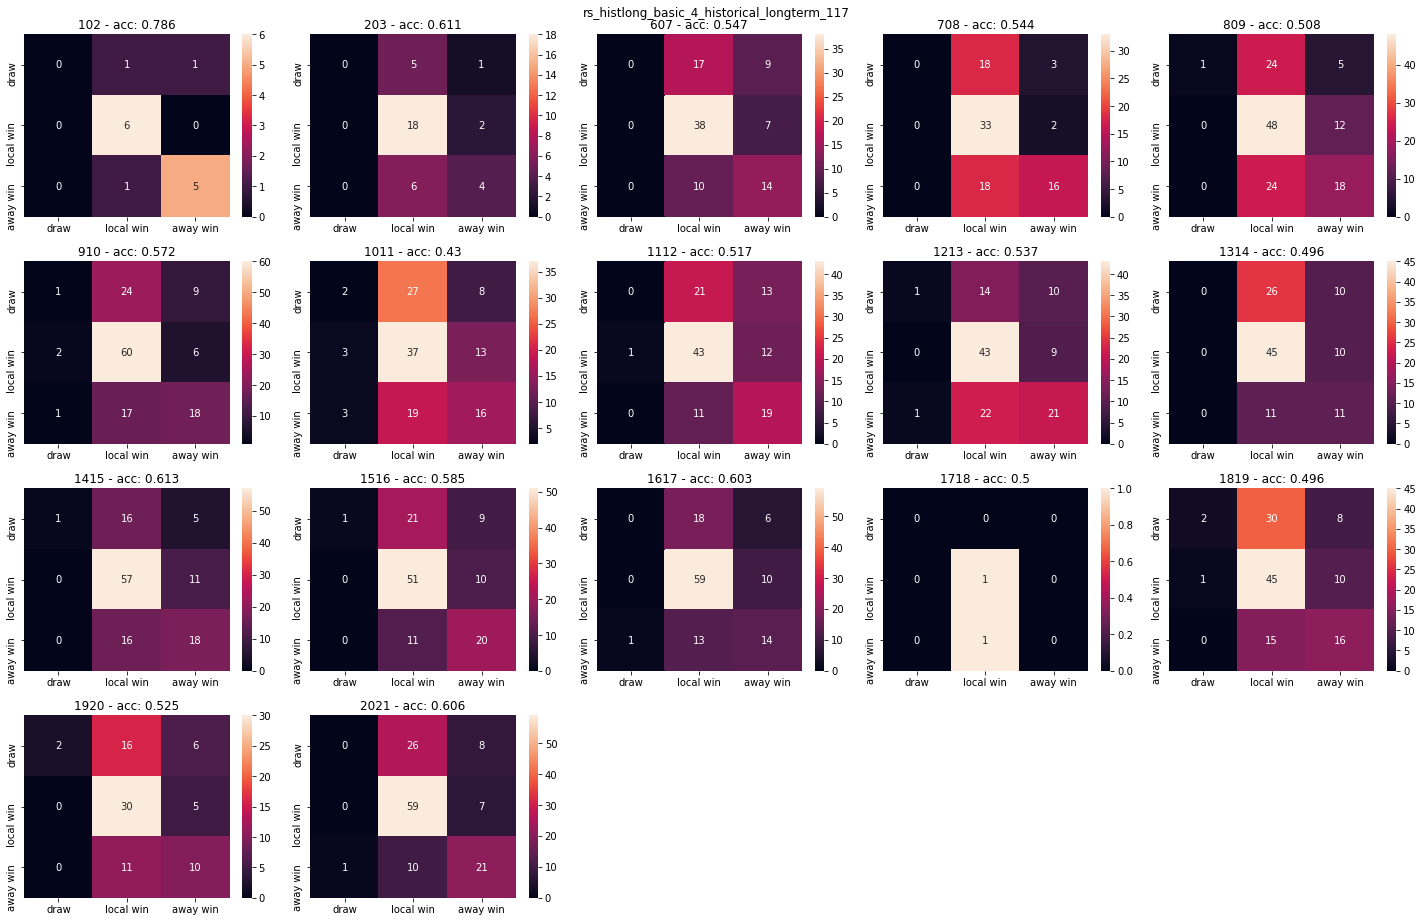

In [126]:
f = plt.figure(0)
f.set_size_inches(20,16)
f.suptitle(title)

for i,m in enumerate(outputs_data.season.unique()):
    ax = f.add_subplot(5,5,i+1)
    conf_data = outputs_data[outputs_data.season==m]
    df_confmat = confusion_matrix(conf_data.label,conf_data.prediction,labels=[0,1,2])
    df_confmat = pd.DataFrame(df_confmat, index=['draw','local win','away win'], columns=['draw','local win','away win'])
    sn.heatmap(df_confmat,annot=True,fmt=".0f")
    ax.set_title(f'{m} - acc: {round(acc_season["isaccurate"]["mean"].loc[m],3)}')
f.tight_layout()
if save: f.savefig(path_summary + f'{title}_season' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')


##### Month accuracy

In [286]:
outputs_data['month'] = outputs_data.Date.apply(lambda x: int(x.split('-')[1]))

In [287]:
acc_month = outputs_data.groupby(['month']).agg({'isaccurate':['mean','count']}) #    .isaccurate.mean().to_frame()
acc_month

isaccurate      
            mean count
month                 
1       0.519149   235
2       0.504739   422
3       0.527851   377
4       0.585938   384
5       0.544444   360
6       0.466667    15
7       0.500000    32
8       0.529412    68
9       0.490683   161
10      0.542636   129
11      0.497976   247
12      0.540909   440

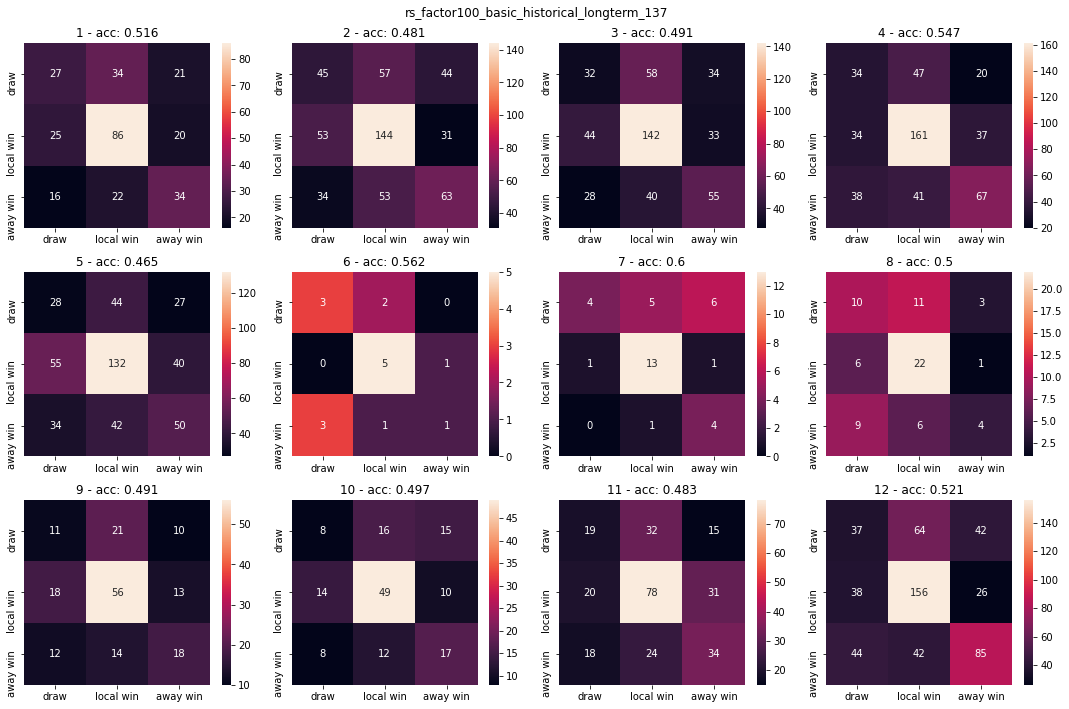

In [188]:
f = plt.figure(0)
f.set_size_inches(15,10)
f.suptitle(title)
for i,m in enumerate(sorted(outputs_data.month.unique())):
    ax = f.add_subplot(3,4,i+1)
    conf_data = outputs_data[outputs_data.month==m]
    df_confmat = confusion_matrix(conf_data.label,conf_data.prediction,labels=[0,1,2])
    df_confmat = pd.DataFrame(df_confmat, index=['draw','local win','away win'], columns=['draw','local win','away win'])
    sn.heatmap(df_confmat,annot=True,fmt=".0f")
    ax.set_title(f'{m} - acc: {round(acc_month["isaccurate"]["mean"].loc[m],3)}')
f.tight_layout()

##### CLUSTERING accuracy

In [398]:
acc_cluster = outputs_data.groupby(['cluster_home','cluster_away']).agg({'isaccurate':['mean','count']}) #    .isaccurate.mean().to_frame()
acc_cluster

isaccurate      
                                mean count
cluster_home cluster_away                 
0            0              0.442543  1636
             1              0.406504   615
             2              0.608939   179
1            0              0.642735   585
             1              0.457317   164
             2              0.500000    42
2            0              0.776536   179
             1              0.760000    50
             2              0.333333     6

[[2 2]
 [1 2]
 [0 2]
 [2 1]
 [1 1]
 [0 1]
 [2 0]
 [1 0]
 [0 0]]
rs_factor100_basic_historical_longterm_137


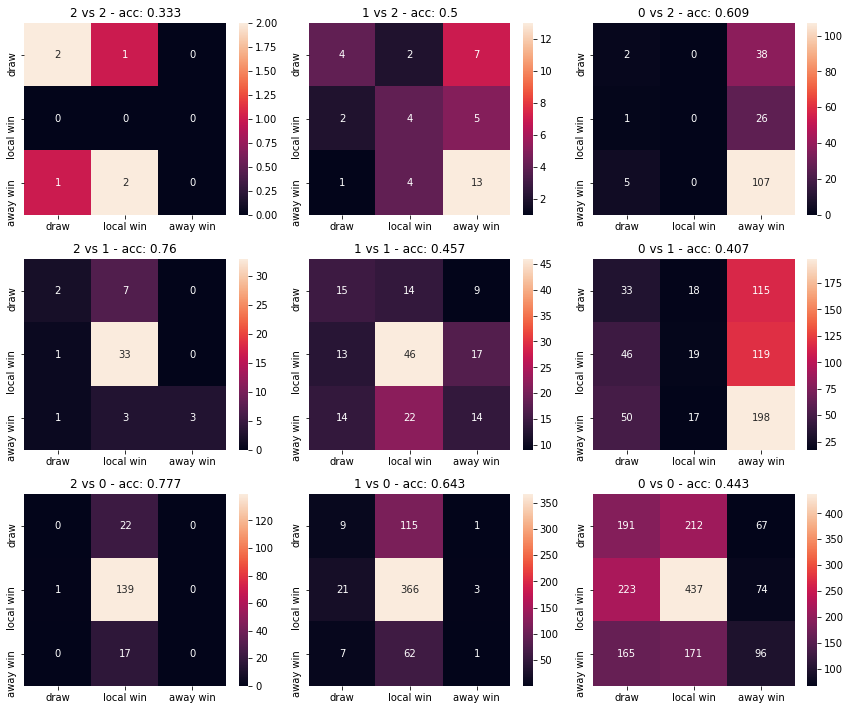

In [399]:
f = plt.figure(0)
f.set_size_inches(12,13)
# f.suptitle(title)
vals = np.array(np.meshgrid(outputs_data.cluster_home.unique(),outputs_data.cluster_home.unique())).reshape(2,len(outputs_data.cluster_home.unique())**2).T
# vals = np.sort(vals)
print(vals)
for i,(h,a) in enumerate(vals):
    ax = f.add_subplot(4,3,i+1)
    conf_data = outputs_data[(outputs_data.cluster_home==h) & (outputs_data.cluster_away==a)]
    df_confmat = confusion_matrix(conf_data.label,conf_data.prediction,labels=[0,1,2])
    df_confmat = pd.DataFrame(df_confmat, index=['draw','local win','away win'], columns=['draw','local win','away win'])
    sn.heatmap(df_confmat,annot=True,fmt=".0f")
    ax.set_title(f'{h} vs {a} - acc: {round(acc_cluster["isaccurate"]["mean"].loc[h,a],3)}')
f.tight_layout()
print(title)
f.savefig(path_summary + f'{title}_3clusters2' + '.jpg', format='jpg', dpi=200, bbox_inches='tight')


#### CLUSTER EQUIPO-TEMPORADA

In [60]:
outputs_data

,matchId,draw_pred,home_pred,away_pred,prediction,label,config.,mode,epoch,HomeTeam,...,Target_1825D_away,Corner_1825D_away,Faults_1825D_away,YellowCards_1825D_away,RedCards_1825D_away,cluster_home,cluster_away,match_cluster,isaccurate,month
16960,559,0.317113,0.233864,0.449023,2.0,2.0,92.0,1.0,199.0,Aston Villa,...,6.090909,5.781818,12.527273,1.345455,0.600000,1,3,-2,True,12
16961,564,0.295648,0.571759,0.132593,1.0,1.0,92.0,1.0,199.0,Ipswich,...,4.160714,4.535714,12.678571,1.678571,0.767857,0,1,-1,True,12
16962,586,0.277735,0.555044,0.167221,1.0,1.0,92.0,1.0,199.0,Man United,...,5.224138,5.775862,14.534483,1.413793,0.568966,3,1,2,True,1
16963,609,0.297899,0.153020,0.549081,2.0,2.0,92.0,1.0,199.0,Leicester,...,7.616667,7.366667,14.033333,1.733333,0.783333,1,3,-2,True,1
16964,636,0.291018,0.547918,0.161064,1.0,1.0,92.0,1.0,199.0,Newcastle,...,4.587302,5.142857,14.142857,1.158730,0.555556,1,1,0,True,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18651,48290,0.318928,0.556727,0.124344,1.0,1.0,92.0,1.0,199.0,Rennes,...,3.708571,4.245714,13.525714,1.902857,1.011429,2,0,2,True,4
18652,48296,0.329619,0.499323,0.171057,1.0,1.0,92.0,1.0,199.0,Lille,...,4.235955,4.365169,11.398876,1.921348,0.921348,2,1,1,True,5
18653,48298,0.386481,0.357246,0.256273,0.0,2.0,92.0,1.0,199.0,Brest,...,3.724719,4.831461,13.320225,1.904494,0.943820,0,1,-1,False,5
18654,48299,0.358910,0.309244,0.331846,0.0,2.0,92.0,1.0,199.0,Dijon,...,3.652174,4.224638,13.275362,1.971014,0.971014,0,0,0,False,5


In [121]:
raw_Data  = pd.read_csv(path_train+'historical_longterm'+'.csv',sep=';',index_col='matchId')#.set_index('wyId')
pd.options.display.max_rows = 200
raw_Data.groupby(['Div','season']).agg({'HomeTeam':['count']})

HomeTeam
              count
Div season         
D1  1           306
    203         306
    607         306
    708         306
    809         306
    910         306
    1011        306
    1112        306
    1213        306
    1314        306
    1415        306
    1516        306
    1617        306
    1718        306
    1819        306
    1920        306
    2021        288
E0  1           380
    102         380
    203         380
    405         380
    607         380
    708         380
    809         380
    910         380
    1011        380
    1112        380
    1213        380
    1314        380
    1415        380
    1516        380
    1617        380
    1718        380
    1819        380
    1920        380
    2021        350
F1  708         380
    809         380
    910         380
    1011        380
    1112        378
    1213        380
    1314        380
    1415        380
    1516        380
    1617        379
    1718        380
    1819        380
    1920        279
    2021        380
I1  506         366
    607         380
    708         380
    809         380
    910         380
    1011        380
    1112        380
    1213        379
    1314        380
    1415        379
    1516        380
    1617        379
    1718        380
    1819        380
    1920        380
    2021        358
SP1 506         380
    607         380
    708         380
    809         380
    910         380
    1011        380
    1112        380
    1213        380
    1314        380
    1415        380
    1516        380
    1617        380
    1718        380
    1819        380
    1920        380
    2021        380

In [148]:
raw_Data  = pd.read_csv(path_train+'historical_longterm'+'.csv',sep=';',index_col='matchId')#.set_index('wyId')

col_home, col_away = 'points_1825D_home', 'points_730D_home'
# col_home, col_away = 'points_365D_home', 'points_365D_away'

top1825_home = raw_Data.groupby(['HomeTeam','season']).agg({col_home:'mean'})
top1825_away = raw_Data.groupby(['HomeTeam','season']).agg({col_away:'mean', 'Div':'first'})
top1825_away

points_730D_home  Div
HomeTeam     season                       
Aachen       708                  NaN   D1
Ajaccio      1112                 NaN   F1
             1213            1.112056   F1
             1314            1.014931   F1
Ajaccio GFCO 1516                 NaN   F1
...                               ...  ...
Zaragoza     708             1.373405  SP1
             910                  NaN  SP1
             1011            1.026046  SP1
             1112            1.087069  SP1
             1213            1.162387  SP1

[1606 rows x 2 columns]

In [149]:
top1825 = pd.merge(
    left=top1825_home.reset_index(), right=top1825_away.reset_index(),
    left_on=['season','HomeTeam'], right_on=['season','HomeTeam'],
    how='inner'
)
top1825

,HomeTeam,season,points_1825D_home,points_730D_home,Div
0,Aachen,708,NaN,NaN,D1
1,Ajaccio,1112,NaN,NaN,F1
2,Ajaccio,1213,1.112056,1.112056,F1
3,Ajaccio,1314,0.999109,1.014931,F1
4,Ajaccio GFCO,1516,NaN,NaN,F1
...,...,...,...,...,...
1601,Zaragoza,708,1.356581,1.373405,SP1
1602,Zaragoza,910,1.255794,NaN,SP1
1603,Zaragoza,1011,1.202819,1.026046,SP1
1604,Zaragoza,1112,1.128988,1.087069,SP1


In [150]:
raw_Data[raw_Data.HomeTeam=='Barcelona'][raw_Data.season==1314][['Date','HomeTeam','AwayTeam','points_365D_home']]

<ipython-input-150-e37cc4e176c1>:1: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



,Date,HomeTeam,AwayTeam,points_365D_home
matchId,,,,
15274,2013-08-18,Barcelona,Levante,2.631579
15302,2013-09-14,Barcelona,Sevilla,2.631579
15322,2013-09-24,Barcelona,Sociedad,2.631579
15343,2013-10-05,Barcelona,Valladolid,2.641026
15362,2013-10-26,Barcelona,Real Madrid,2.641026
15381,2013-11-01,Barcelona,Espanol,2.650000
15404,2013-11-23,Barcelona,Granada,2.641026
15422,2013-12-14,Barcelona,Villarreal,2.552632
15445,2014-01-05,Barcelona,Elche,2.552632


In [151]:
plotly.scatter(top1825,col_home,col_away,hover_name='HomeTeam',hover_data=['season'],color='Div',width=1200,height=700)
# plotly.line(np.arange)

## INSIGHTS

In [220]:
def dispConfusionMatrix(matrix,title,size=(10,7)):
    # if save and filename=='': return 'Please, add a valid filename'
    df_confmat = pd.DataFrame(matrix, index=['draw','local win','away win'], columns=['draw','local win','away win'])
    plt.figure(figsize=size)
    plt.title(title)
    sns.heatmap(df_confmat,annot=True,fmt=".0f",square=True)
    plt.xlabel('Prediction',fontsize=12)
    plt.ylabel('Ground truth',fontsize=12)

def f1_score(conf_matrix):
    conf_matrix = np.array(conf_matrix)
    precision = (precision_score(conf_matrix))
    recall = recall_score(conf_matrix)
    f1 = 2 * (precision * recall) / (precision + recall)
    return np.nan_to_num(f1,0)

def recall_score(conf_matrix):
    conf_matrix = np.array(conf_matrix)
    tpfn = np.sum(conf_matrix,axis=1)
    tp = conf_matrix.diagonal()
    return tp/tpfn

def precision_score(conf_matrix):
    conf_matrix = np.array(conf_matrix)
    tpfn = np.sum(conf_matrix,axis=0)
    tp = conf_matrix.diagonal()
    recall = tp/tpfn
    recall = np.nan_to_num(recall)
    return recall

In [239]:
path_outputs = "F:\\TFG\\results\\outputs\\"


In [258]:
title = "rs_nofactor_basic_historical_longterm_58"
outputs = pd.read_csv(path_outputs+f'{title}.csv',sep=';',decimal=',').drop('Unnamed: 0',axis=1)
# outputs = pd.read_csv(path_outputs+f'{title}\\' + "rs_hl_basic_historical_longterm_36" + ".csv",sep=';',decimal=',').drop('Unnamed: 0',axis=1)
outputs = outputs[(outputs.epoch==49) & (outputs['mode']==1) & (outputs['config.']==58)]

In [11]:
# outputs.merge(outputs1['matchId'], on='matchId',how='inner')
# outputs = outputs.sample(256,random_state=1)
outputs

,matchId,match,draw,home,away,prediction,label
0,26,26,0.291247,0.301965,0.406787,2,0
1,155,155,0.175490,0.727552,0.096959,1,1
2,183,183,0.255657,0.476591,0.267753,1,2
3,195,195,0.307430,0.245962,0.446608,2,1
4,196,196,0.285401,0.413913,0.300687,1,1
...,...,...,...,...,...,...,...
2371,2576303,2576303,0.209451,0.284760,0.505789,2,2
2372,2576309,2576309,0.190485,0.611402,0.198113,1,0
2373,2576331,2576331,0.296163,0.485301,0.218536,1,1
2374,2576333,2576333,0.275434,0.530185,0.194381,1,1


In [260]:
def cols2softmax(data,cols):
    preds = torch.tensor(data[cols].to_numpy())
    data[cols] = torch.softmax(preds,dim=1).numpy()
    return data

In [30]:
# data = cols2softmax(outputs,["draw_pred","home_pred","away_pred"])
data = outputs

In [31]:
preds = data[["draw","home","away"]]
# preds = data[["draw_pred","home_pred","away_pred"]]
data

,matchId,match,draw,home,away,prediction,label
0,26,26,0.287430,0.306186,0.406384,2,0
1,155,155,0.136682,0.777098,0.086220,1,1
2,183,183,0.221852,0.488442,0.289705,1,2
3,195,195,0.270842,0.267870,0.461288,2,1
4,196,196,0.280639,0.432279,0.287082,1,1
...,...,...,...,...,...,...,...
2371,2576303,2576303,0.214562,0.307715,0.477722,2,2
2372,2576309,2576309,0.179091,0.649997,0.170913,1,0
2373,2576331,2576331,0.289030,0.480433,0.230537,1,1
2374,2576333,2576333,0.247460,0.496122,0.256418,1,1


In [225]:
data['home_pred'] = data['home_pred'] - 0.1
data['away_pred'] = data['away_pred'] + 0.03
data['draw_pred'] = data['draw_pred'] + 0.07
preds = data[["draw_pred","home_pred","away_pred"]]
data['prediction'] = preds.to_numpy().argmax(axis=1)

In [263]:
data

,matchId,draw_pred,home_pred,away_pred,prediction,label,config.,mode,epoch,HomeTeam,AwayTeam,FTR,FTHG,FTAG
187328,155.0,0.205767,0.685958,0.108275,1.0,1.0,58.0,1.0,49.0,Man United,Tottenham,1,2.0,0.0
187329,183.0,0.275859,0.552062,0.172079,1.0,2.0,58.0,1.0,49.0,Leeds,Aston Villa,2,1.0,2.0
187330,191.0,0.346967,0.284585,0.368448,2.0,2.0,58.0,1.0,49.0,Bradford,Sunderland,2,1.0,4.0
187331,195.0,0.339005,0.191378,0.469617,2.0,1.0,58.0,1.0,49.0,Middlesbrough,Liverpool,1,1.0,0.0
187332,196.0,0.335403,0.277547,0.387050,2.0,1.0,58.0,1.0,49.0,Newcastle,Leeds,1,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190779,2576154.0,0.220346,0.107463,0.672191,2.0,2.0,58.0,1.0,49.0,Cagliari,Juventus,2,0.0,1.0
190780,2576179.0,0.243077,0.631907,0.125015,1.0,1.0,58.0,1.0,49.0,Atalanta,Chievo,1,1.0,0.0
190781,2576182.0,0.217239,0.684276,0.098485,1.0,2.0,58.0,1.0,49.0,Lazio,Genoa,2,1.0,2.0
190782,2576190.0,0.172597,0.771851,0.055552,1.0,1.0,58.0,1.0,49.0,Roma,Benevento,1,5.0,2.0


In [264]:
mask = data['label']

In [32]:
from sklearn.metrics import confusion_matrix as confmat
cm = confmat(data['label'],data['prediction'],labels=[0,1,2])
cm

array([[   2,  481,  132],
       [   1, 1015,  117],
       [   1,  380,  247]], dtype=int64)

In [33]:
cm.diagonal().sum() / cm.sum()

0.531986531986532

In [34]:
cm.sum(axis=0) / cm.sum()

array([0.0016835 , 0.78956229, 0.20875421])

In [332]:
cm = [
            [
                15.0,
                37.0,
                10.0
            ],
            [
                29.0,
                67.0,
                19.0
            ],
            [
                21.0,
                29.0,
                29.0
            ]
        ]

cm = np.array(cm)
cm.sum(axis=0) / cm.sum()

array([0.25390625, 0.51953125, 0.2265625 ])

In [268]:
cm.sum(axis=1) / cm.sum()

array([0.25636574, 0.46180556, 0.2818287 ])

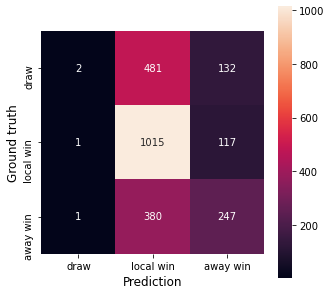

In [35]:
dispConfusionMatrix(cm,"",size=(5,5))
title = 'rs_nofactor_basic_historical_longterm_58'
plt.savefig(path_summary + f'confmat_{title}.jpg', format='jpg', dpi=200,bbox_inches='tight')


In [28]:
data.to_csv(path_outputs + title + '\\' + title + "_v2.csv",decimal=',',sep=';')

In [36]:
from sklearn.metrics import RocCurveDisplay

def one_hot_vector(vector):
    one_hot_vector = np.zeros((vector.size, vector.max()+1), dtype=int)
    one_hot_vector[np.arange(vector.size),vector] = 1 
    return one_hot_vector

In [38]:
def plot_aucroc(labels,encoded_pred,title,save=True):
    encoded_res = one_hot_vector(labels)
    encoded_res.shape == encoded_pred.shape

    class_id = 0
    class_of_interest = 'Draws'

    fig = plt.figure(figsize=(12,9))

    ax = fig.add_subplot(1,3,1)
    RocCurveDisplay.from_predictions(
        encoded_res[:, class_id],
        encoded_pred[:, class_id],
        name=f"{class_of_interest} vs the rest",
        color="darkorange",
        ax=ax
    )

    # ax.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")
    plt.axis("square")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    # ax.set_title(f"\n{class_of_interest} vs (HomeWins & AwayWins)")

    ##################

    class_id = 1
    class_of_interest = 'Home wins'

    # ax = fig.add_subplot(1,3,2)
    RocCurveDisplay.from_predictions(
        encoded_res[:, class_id],
        encoded_pred[:, class_id],
        name=f"{class_of_interest} vs the rest",
        color="darkgreen",
        ax=ax
    )

    # ax.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")
    plt.axis("square")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    # ax.set_title(f"\n{class_of_interest} vs (HomeWins & Draws)")

    ##################

    class_id = 2
    class_of_interest = 'Away wins'

    # ax = fig.add_subplot(1,3,3)
    RocCurveDisplay.from_predictions(
        encoded_res[:, class_id],
        encoded_pred[:, class_id],
        name=f"{class_of_interest} vs the rest",
        color="darkred",
        ax=ax
    )

    ax.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)")
    plt.axis("square")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    # ax.set_title(f"\n{class_of_interest} vs (Draws & AwayWins)")
    ax.set_title(f"\nAUC-ROC")

    fig.tight_layout()
    plt.legend()
    if save: fig.savefig(path_summary + f'aucroc_{title}.jpg', format='jpg', dpi=200,bbox_inches='tight')
    plt.show()

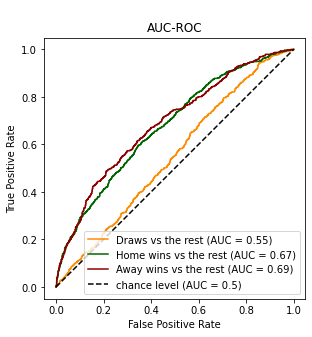

In [39]:
plot_aucroc(data['label'].astype(int),preds.to_numpy(),title + '_lgbm',save=True)

#### ERROR OVER TIME

In [212]:
save=False
title = 'rs_histlong_basic_5_historical_longterm_62'
m62 = pd.read_csv(path_outputs+f'{title}.csv',sep=';',decimal=',').drop('Unnamed: 0',axis=1)
m62 = m62[(m62.epoch==49) & (m62['mode']==1) & (m62['config.']==62)]

title = 'rs_dimredhgd_pca_15_10'
m117 = pd.read_csv(path_outputs+f'{title}.csv',sep=';',decimal=',').drop('Unnamed: 0',axis=1)
m117 = m117[(m117.epoch==99) & (m117['mode']==1) & (m117['config.']==10)]

In [213]:
m117.columns

Index(['matchId', 'draw_pred', 'home_pred', 'away_pred', 'prediction', 'label',
       'config.', 'mode', 'epoch', 'HomeTeam', 'AwayTeam', 'FTR', 'FTHG',
       'FTAG'],
      dtype='object')

In [214]:
def cols2softmax(data,cols):
    preds = torch.tensor(data[cols].to_numpy())
    data[cols] = torch.softmax(preds,dim=1).numpy()
    return data

m117 = cols2softmax(m117,["draw_pred","home_pred","away_pred"])

In [215]:
m117

,matchId,draw_pred,home_pred,away_pred,prediction,label,config.,mode,epoch,HomeTeam,AwayTeam,FTR,FTHG,FTAG
469728,21,0.244227,0.509777,0.245997,1,0,10,1,99,Everton,Derby,0,2,2
469729,23,0.237548,0.522101,0.240351,1,2,10,1,99,Man City,Coventry,2,1,2
469730,26,0.229224,0.536242,0.234534,1,0,10,1,99,Southampton,Liverpool,0,3,3
469731,39,0.251311,0.345118,0.403571,2,0,10,1,99,Bradford,Arsenal,0,1,1
469732,49,0.182597,0.654659,0.162744,1,1,10,1,99,Arsenal,Coventry,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475643,2565898,0.261776,0.359886,0.378339,2,2,10,1,99,Las Palmas,Getafe,2,0,1
475644,2565913,0.237659,0.538586,0.223755,1,2,10,1,99,Getafe,Ath Madrid,2,0,1
475645,2565924,0.247246,0.515553,0.237201,1,1,10,1,99,Valencia,La Coruna,1,2,1
475646,2576058,0.270545,0.431105,0.298350,1,2,10,1,99,Sassuolo,Udinese,2,0,1


In [216]:
# df_merged_m62 = m62.merge(raw_Data['Date'],left_on='matchId',right_index=True,how='left')
# df_merged_m117 = m117.merge(raw_Data['Date'],left_on='matchId',right_index=True,how='left')
# df_merged_m62

In [217]:
from torch.nn import functional as nnf
from torch.nn import CrossEntropyLoss as CE

In [218]:
labels_m62 = nnf.one_hot(torch.tensor(m62.label.to_numpy())).float()
preds_m62 = torch.tensor(m62[["draw_pred","home_pred","away_pred"]].to_numpy())

labels_m117 = nnf.one_hot(torch.tensor(m117.label.to_numpy())).float()
preds_m117 = torch.tensor(m117[["draw_pred","home_pred","away_pred"]].to_numpy())

In [219]:
labels_m62

tensor([[0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        ...,
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.]])

In [220]:
ce = CE(reduction ='none')
error_sample_m62 = ce(labels_m62,preds_m62)
error_sample_m117 = ce(labels_m117,preds_m117)

In [221]:
m62["sample_error"] = error_sample_m62.numpy()
m117["sample_error"] = error_sample_m117.numpy()

m117

,matchId,draw_pred,home_pred,away_pred,prediction,label,config.,mode,epoch,HomeTeam,AwayTeam,FTR,FTHG,FTAG,sample_error
469728,21,0.244227,0.509777,0.245997,1,0,10,1,99,Everton,Derby,0,2,2,1.307218
469729,23,0.237548,0.522101,0.240351,1,2,10,1,99,Man City,Coventry,2,1,2,1.311094
469730,26,0.229224,0.536242,0.234534,1,0,10,1,99,Southampton,Liverpool,0,3,3,1.322221
469731,39,0.251311,0.345118,0.403571,2,0,10,1,99,Bradford,Arsenal,0,1,1,1.300133
469732,49,0.182597,0.654659,0.162744,1,1,10,1,99,Arsenal,Coventry,1,2,1,0.896786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475643,2565898,0.261776,0.359886,0.378339,2,2,10,1,99,Las Palmas,Getafe,2,0,1,1.173106
475644,2565913,0.237659,0.538586,0.223755,1,2,10,1,99,Getafe,Ath Madrid,2,0,1,1.327690
475645,2565924,0.247246,0.515553,0.237201,1,1,10,1,99,Valencia,La Coruna,1,2,1,1.035892
475646,2576058,0.270545,0.431105,0.298350,1,2,10,1,99,Sassuolo,Udinese,2,0,1,1.253094


In [222]:
cols = ["draw_pred","home_pred","away_pred","prediction","sample_error"]
m117 = m117.set_index('matchId')[cols].add_suffix("_117")
m62 = m62.set_index('matchId')[cols].add_suffix("_62")

df = m117.join(m62,how='inner')
df

df = df.join(raw_Data['Date'],how='left')

In [223]:
df['Date'] = df.Date.map(lambda x: datetime.datetime.strptime(x,'%Y-%m-%d'))
df["week_of_year"] = df.Date.map(lambda d: d.week)

In [226]:
error_week = df.groupby('week_of_year').agg({"sample_error_117":"mean","sample_error_62":"mean"})

<AxesSubplot:xlabel='week_of_year', ylabel='sample_error_117'>

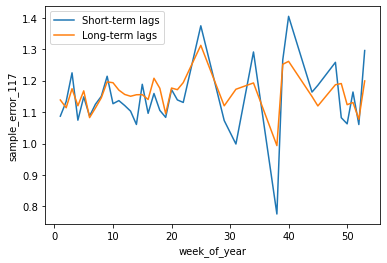

In [228]:
sns.lineplot(data=error_week,x='week_of_year',y='sample_error_117',label='Short-term lags')
sns.lineplot(data=error_week,x='week_of_year',y='sample_error_62',label='Long-term lags')

In [231]:
error_week[["sample_error_117","sample_error_62"]].mean()

sample_error_117    1.144010
sample_error_62     1.158944
dtype: float64

##### ERROR vs ACCURACY

In [631]:
title = 'bets_vs_f1'

In [632]:
best_vs_factors = pd.read_csv(path_outputs + title + '.csv', sep=';',decimal=',')

In [633]:
best_vs_factors['res'] = best_vs_factors.HTR.map({'D':0,'H':1,'A':2})
best_vs_factors

,matchId,draw_pred_117,home_pred_117,away_pred_117,prediction_117,draw_pred_62,home_pred_62,away_pred_62,prediction_62,Div,...,Received_1825D_away,points_1825D_away,Shots_1825D_away,Target_1825D_away,Corner_1825D_away,Faults_1825D_away,YellowCards_1825D_away,RedCards_1825D_away,year,res
0,23201.0,0.2632,0.1818,0.6211,2,0.3255,0.2433,0.4311,2.0,D1,...,48.0,1.9000,17.6600,8.9600,6.4200,16.2400,1.5600,0.6200,2007,0
1,23203.0,0.2500,0.6667,0.1481,1,0.2825,0.5484,0.1691,1.0,D1,...,58.0,1.2600,14.7600,6.9200,4.8600,18.0000,1.9200,0.9000,2007,1
2,23254.0,0.2941,0.2667,0.5000,2,0.3256,0.2434,0.4311,2.0,D1,...,56.0,1.8393,15.6607,7.3750,6.0893,18.7857,1.9286,0.8036,2008,2
3,23263.0,0.3030,0.3226,0.4348,2,0.3256,0.2434,0.4311,2.0,D1,...,75.0,1.8772,16.2281,7.8947,5.7018,18.0175,1.6667,0.8421,2008,1
4,23269.0,0.2667,0.6211,0.1818,1,0.2865,0.5504,0.1631,1.0,D1,...,68.0,1.1579,14.6842,6.5088,4.7193,17.9825,1.9474,0.9298,2008,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1664,18270.0,0.2500,0.6369,0.1739,1,0.3015,0.5106,0.1879,1.0,SP1,...,212.0,1.3690,11.1925,4.0160,4.9786,13.8717,2.5080,1.2888,2021,0
1665,18279.0,0.2667,0.5263,0.2667,1,0.2995,0.5212,0.1793,1.0,SP1,...,218.0,1.7594,13.1123,4.6524,5.4492,14.2299,2.6417,1.3316,2021,2
1666,18289.0,0.3077,0.3571,0.3922,2,0.3587,0.3068,0.3345,0.0,SP1,...,285.0,1.3138,11.6915,4.2500,4.5532,12.9521,2.5319,1.3032,2021,2
1667,18293.0,0.1739,0.8197,0.0667,1,0.2815,0.5696,0.1490,1.0,SP1,...,193.0,1.0536,10.8214,3.6875,3.8929,14.4464,2.5446,1.3661,2021,0


In [634]:
cols = ['res','draw_pred_117',	'home_pred_117','away_pred_117','draw_pred_62','home_pred_62','away_pred_62']
# cols = ['res','draw_pred_bet',	'home_pred_bet','away_pred_bet','draw_pred_fac','home_pred_fac','away_pred_fac']
# cols = ['res','draw_pred_bets',	'home_pred_bets','away_pred_bets','draw_pred_best','home_pred_best','away_pred_best']

In [635]:
best_vs_factors = best_vs_factors[cols]

In [636]:
preds_fac = best_vs_factors[['draw_pred_62','home_pred_62','away_pred_62']].to_numpy()
preds_bet = best_vs_factors[['draw_pred_117',	'home_pred_117','away_pred_117']].to_numpy()
# preds_fac = best_vs_factors[['draw_pred_fac','home_pred_fac','away_pred_fac']].to_numpy()
# preds_bet = best_vs_factors[['draw_pred_bet',	'home_pred_bet','away_pred_bet']].to_numpy()
# preds_fac = best_vs_factors[['draw_pred_best','home_pred_best','away_pred_best']].to_numpy()
# preds_bet = best_vs_factors[['draw_pred_bets',	'home_pred_bets','away_pred_bets']].to_numpy()

In [637]:
decision = preds_fac.argmax(axis=1)
decision

array([2, 1, 2, ..., 0, 1, 1], dtype=int64)

In [638]:
preds_fac = preds_fac[np.arange(preds_fac.shape[0]), decision]
preds_bet = preds_bet[np.arange(preds_bet.shape[0]), decision]

In [639]:
is_ok = decision==best_vs_factors['res']

In [640]:
pd_final = pd.DataFrame({'preds':preds_fac,'bets':preds_bet,'Accurated: ':is_ok}).sort_values('Accurated: ')

In [641]:
pd_final.sort_values('Accurated: ')

,preds,bets,Accurated:
0,0.4311,0.6211,False
159,0.4311,0.5236,False
157,0.4307,0.5000,False
156,0.6189,0.7519,False
155,0.4581,0.4878,False
...,...,...,...
1422,0.4313,0.7143,True
1557,0.6208,0.8850,True
1423,0.5305,0.6173,True
1416,0.4220,0.6667,True


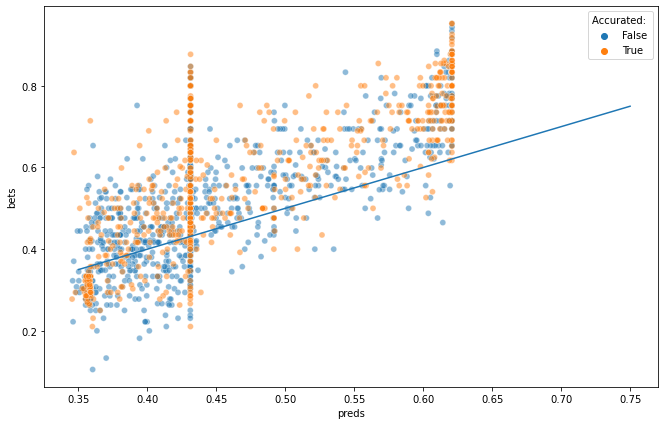

In [642]:
plt.figure(figsize=(11,7))
sns.scatterplot(data=pd_final,x='preds',y='bets',hue='Accurated: ',alpha=.5)
plt.plot([0.35,.75],[0.35,.75])
plt.savefig(path_summary + f'scatter_bets_vs_f1.jpg', format='jpg', dpi=200,bbox_inches='tight')

In [643]:
pd_final['is_bigger'] = pd_final.preds > pd_final.bets

In [644]:
pd_final.groupby(['Accurated: ','is_bigger']).preds.count().to_frame() / len(pd_final)

preds
Accurated:  is_bigger          
False       False      0.393050
            True       0.203715
True        False      0.303176
            True       0.100060

In [546]:
pd_final.groupby(['Acierto: ','is_bigger']).preds.count().to_frame() / len(pd_final)

preds
Acierto:  is_bigger          
False     False      0.375075
          True       0.216297
True      False      0.301378
          True       0.107250

In [529]:
pd_final.groupby(['Acierto: ','is_bigger']).preds.mean().to_frame()

preds
Acierto:  is_bigger          
False     False      0.481594
          True       0.427957
True      False      0.508095
          True       0.417610

In [547]:
pd_final.groupby(['Acierto: ','is_bigger']).preds.mean().to_frame()

preds
Acierto:  is_bigger          
False     False      0.486933
          True       0.456673
True      False      0.512502
          True       0.465083

In [530]:
pd_final.groupby(['Acierto: ','is_bigger']).bets.mean().to_frame()

bets
Acierto:  is_bigger          
False     False      0.592926
          True       0.365559
True      False      0.641745
          True       0.359499

##### CONFIDENCE INTERVAL

In [713]:
ci = 0.05
title = 'bets'
m62 = pd.read_csv(path_outputs+f'{title}.csv',sep=';',decimal=',').drop('Unnamed: 0',axis=1,errors='ignore')
# m62 = m62[(m62.epoch==49) & (m62['mode']==1) & (m62['config.']==62)]
outputs = m62
outputs['matchId'] = outputs.matchId.astype(int)

In [714]:
outputs.shape

(31157, 6)

In [715]:
def cols2softmax(data,cols):
    preds = torch.tensor(data[cols].to_numpy())
    data[cols] = torch.softmax(preds,dim=1).numpy()
    return data

# outputs = cols2softmax(outputs,["draw_pred","home_pred","away_pred"])

In [716]:
outputs = outputs[['draw_pred','home_pred','away_pred','label']]
outputs

,draw_pred,home_pred,away_pred,label
0,0.307692,0.526316,0.285714,1
1,0.294118,0.636943,0.181818,2
2,0.307692,0.476190,0.333333,0
3,0.307692,0.307692,0.500000,2
4,0.307692,0.546448,0.266667,0
...,...,...,...,...
31152,0.230947,0.200000,0.621118,2
31153,0.200000,0.714286,0.153846,1
31154,0.190476,0.111111,0.751880,2
31155,0.294118,0.381679,0.384615,0


In [717]:
preds = outputs[['draw_pred','home_pred','away_pred']]

In [718]:
preds

,draw_pred,home_pred,away_pred
0,0.307692,0.526316,0.285714
1,0.294118,0.636943,0.181818
2,0.307692,0.476190,0.333333
3,0.307692,0.307692,0.500000
4,0.307692,0.546448,0.266667
...,...,...,...
31152,0.230947,0.200000,0.621118
31153,0.200000,0.714286,0.153846
31154,0.190476,0.111111,0.751880
31155,0.294118,0.381679,0.384615


In [719]:
preds_ci = {}
for c in preds.columns:
    preds_ci[c] = {}
    preds_ci[c]['+'] = preds[c] + (preds[c]*ci)
    preds_ci[c]['-'] = preds[c] - (preds[c]*ci)
    preds_ci[c]['='] = preds[c]
    preds_ci[c] = pd.concat([preds_ci[c]['+'],preds_ci[c]['-'],preds_ci[c]['=']])

In [720]:
pd_cross = preds_ci['draw_pred'].to_frame().join(preds_ci['home_pred'].to_frame()).join(preds_ci['away_pred'].to_frame())
pd_cross

,draw_pred,home_pred,away_pred
0,0.323077,0.552632,0.300000
0,0.323077,0.552632,0.271429
0,0.323077,0.552632,0.285714
0,0.323077,0.500000,0.300000
0,0.323077,0.500000,0.271429
...,...,...,...
31156,0.230947,0.633333,0.146154
31156,0.230947,0.633333,0.153846
31156,0.230947,0.666667,0.161538
31156,0.230947,0.666667,0.146154


In [721]:
pd_cross['res'] = pd_cross.index.map(outputs.label.to_dict())

In [722]:
pd_cross['pred'] = pd_cross[['draw_pred','home_pred','away_pred']].to_numpy().argmax(axis=1)

In [723]:
pd_cross['is_acc'] = pd_cross.res==pd_cross.pred

In [724]:
indices = pd_cross.reset_index().groupby('index').is_acc.max().index

In [725]:
matches_ic = pd_cross.reset_index().groupby('index').is_acc.max()
matches_ic.mean()

0.5524280258047951

In [726]:
matches_ic = pd_cross.reset_index().groupby('index').is_acc.min()
matches_ic.mean()

0.504156369355201